# Figures Generations Notebook
Author: Timothé LUCAS

In [16]:
# ==============================================================================

import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats

# Local deconvolution utilities
sys.path.append("../notebooks")
from util.utils import load_deconvolution_assets, compute_instantaneous_rate, correct_rnap_inactivation

# Configure publication-quality plot parameters (Nature/ACS guidelines)

plt.rcParams.update({
    "font.family": "Arial",
    "mathtext.fontset": "cm",
    "font.size": 12,
    "axes.labelsize": 14,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "axes.linewidth": 1.2,
    "xtick.major.width": 1.2,
    "ytick.major.width": 1.2,
    "figure.dpi": 600,
    "savefig.dpi": 600,
})

# ------------------------------------------------------------------------------


###  DECONVOLUTION / FITTING HYPERPARAMETERS


In [17]:
# ------------------------------------------------------------------------------

LAMBDA_REG = 0.5           # Tikhonov regularization factor
WINDOW_MIN = 65             # Savitzky-Golay integration window (min)

DATA_PATH = Path("../data/processed/TX_with_k_inact.csv")
ASSETS_PATH = Path("../notebooks/util/deconv_assets.pkl")

df = pd.read_csv(DATA_PATH)

_, f_kernel, alpha_slope, DT_MIN = load_deconvolution_assets(ASSETS_PATH)

# ------------------------------------------------------------------------------


Successfully loaded assets from: ../notebooks/util/deconv_assets.pkl


### Analysis architecture example:

In [18]:
#1. IMPORTS
#   │
#  ├── numpy
#   ├── pandas
#   ├── matplotlib
#   ├── scipy
#   └── utils
#          │
#          └── load_deconvolution_assets
#          └── compute_instantaneous_rate
#          └── correct_rnap_inactivation

#2. LOAD DATA
#   │
#   └── df
#
#3. LOAD DECONVOLUTION ASSETS
#   │
#   └── ASSETS_PATH
#          │
#          └── f_kernel
#          └── alpha_slope
#          └── DT_MIN
#
#4. SELECT WELLS / EXPERIMENTS
#   │
#   └── df_1
#
#5. ANALYZE WELLS
#   │
#   └── analyze_wells()
#          │
#          ├── RFU
#          │    ↓
#          │   deconvolution
#          │    ↓
#          │   RNA_cumulated
#          │    ↓
#          │   rate_instantaneous
#          │
#          └── k_inact_exp_mean
#               k_inact_exp_se
#                    ↓
#              RNAP correction
#                    ↓
#              rate_corrected
#
#6. RESULTS
#   │
#   └── results

#7. PLOTS / STATISTICS
#  └── utiliser results

In [19]:
## Built Fonction : ##

def analyze_wells(
    df,
    blank_df,
    f_kernel,
    alpha_slope,
    dt_min,
    exp_col="Exp_ID",
    well_col="Well",
    cycle_col="Cycle",
    time_col="time_min",
    signal_col="RFU",
    blank_template="BLANK",
    lambda_reg=0.5,
    window_min=50.0,
    polyorder=2,
    mode="interp",
):
    """
    Analyze selected transcription wells.

    Processing pipeline
    -------------------
    1. Match each experimental well with the BLANK of the same Exp_ID
       and Cycle.
    2. Subtract the cycle-specific BLANK RFU.
    3. Compute cumulative RNA and instantaneous transcription rate
       by Tikhonov deconvolution.
    4. Retrieve k_inact directly from the experimental dataset.
    5. Correct the instantaneous rate for RNAP inactivation.
    6. Preserve the main experimental metadata.

    Parameters
    ----------
    df : pandas.DataFrame
        Experimental wells to analyze.

    blank_df : pandas.DataFrame
        Original dataset containing BLANK wells.

    f_kernel : array-like
        Deconvolution kernel.

    alpha_slope : float
        RFU-to-RNA calibration slope.

    dt_min : float
        Time step in minutes.

    blank_template : str
        Value identifying the BLANK DNA template.

    mode : str
        Savitzky-Golay edge handling.
        "interp" reproduces the previous analysis behavior.
    """

    # ==================================================================
    # 1. VALIDATION
    # ==================================================================

    required_columns = {
        exp_col,
        well_col,
        cycle_col,
        time_col,
        signal_col,
        "DNA Template",
        "[DNA] (nM)",
        "[RNAP] (nM)",
        "Gyr (U)",
        "TopoI (U)",
        "k_inact_exp_mean",
        "k_inact_exp_se",
    }

    missing = required_columns - set(df.columns)

    if missing:
        raise ValueError(
            f"Missing required columns in df: {sorted(missing)}"
        )

    blank_required = {
        exp_col,
        cycle_col,
        signal_col,
        "DNA Template",
    }

    missing_blank = blank_required - set(blank_df.columns)

    if missing_blank:
        raise ValueError(
            f"Missing required columns in blank_df: "
            f"{sorted(missing_blank)}"
        )

    if not np.isfinite(alpha_slope):
        raise ValueError(
            f"alpha_slope must be finite. Got {alpha_slope}"
        )

    if not np.isfinite(dt_min) or dt_min <= 0:
        raise ValueError(
            f"dt_min must be positive. Got {dt_min}"
        )

    f_kernel = np.asarray(f_kernel, dtype=float)

    if f_kernel.ndim != 1 or len(f_kernel) == 0:
        raise ValueError(
            "f_kernel must be a non-empty 1D array."
        )

    # ==================================================================
    # 2. EXTRACT BLANK WELLS
    # ==================================================================

    blanks = blank_df[
        blank_df["DNA Template"].eq(blank_template)
    ].copy()

    if blanks.empty:
        raise ValueError(
            f"No BLANK wells found with "
            f"DNA Template == '{blank_template}'."
        )

    # --------------------------------------------------------------
    # Check one BLANK per Exp_ID
    # --------------------------------------------------------------

    blank_counts = (
        blanks.groupby(exp_col)[well_col]
        .nunique()
    )

    multiple_blanks = blank_counts[blank_counts > 1]

    if not multiple_blanks.empty:
        raise ValueError(
            "More than one BLANK well found for: "
            f"{multiple_blanks.index.tolist()}"
        )

    # --------------------------------------------------------------
    # Build lookup: Exp_ID + Cycle -> blank RFU
    # --------------------------------------------------------------

    blank_lookup = blanks[
        [exp_col, cycle_col, signal_col]
    ].copy()

    duplicate_blank_cycles = (
        blank_lookup
        .groupby([exp_col, cycle_col])
        .size()
    )

    duplicates = duplicate_blank_cycles[
        duplicate_blank_cycles > 1
    ]

    if not duplicates.empty:
        raise ValueError(
            "Multiple BLANK RFU values found for some "
            "Exp_ID / Cycle combinations."
        )

    blank_lookup = blank_lookup.rename(
        columns={
            signal_col: "RFU_blank"
        }
    )

    # ==================================================================
    # 3. RESULTS CONTAINER
    # ==================================================================

    results = []

    # ==================================================================
    # 4. ANALYZE EACH WELL
    # ==================================================================

    for (exp_id, well), well_df in df.groupby(
        [exp_col, well_col],
        sort=False
    ):

        # --------------------------------------------------------------
        # Prepare well trace
        # --------------------------------------------------------------

        trace = (
            well_df[
                [
                    exp_col,
                    well_col,
                    cycle_col,
                    time_col,
                    signal_col,
                    "DNA Template",
                    "[DNA] (nM)",
                    "[RNAP] (nM)",
                    "Gyr (U)",
                    "TopoI (U)",
                    "k_inact_exp_mean",
                    "k_inact_exp_se",
                ]
            ]
            .dropna(subset=[cycle_col, time_col, signal_col])
            .sort_values(cycle_col)
            .copy()
        )

        if len(trace) < 3:
            print(
                f"Skipping {exp_id} / {well}: "
                f"only {len(trace)} valid points."
            )
            continue

        # --------------------------------------------------------------
        # Add corresponding BLANK
        # --------------------------------------------------------------

        trace = trace.merge(
            blank_lookup,
            on=[exp_col, cycle_col],
            how="left",
            validate="many_to_one",
        )

        missing_blank = trace["RFU_blank"].isna()

        if missing_blank.any():
            missing_cycles = (
                trace.loc[missing_blank, cycle_col]
                .tolist()
            )

            raise ValueError(
                f"{exp_id} / {well}: missing BLANK values "
                f"for cycles {missing_cycles}"
            )

        # --------------------------------------------------------------
        # Blank-corrected RFU
        # --------------------------------------------------------------

        trace["RFU_corrected"] = (
            trace[signal_col]
            - trace["RFU_blank"]
        )

        # --------------------------------------------------------------
        # Time and signal
        # --------------------------------------------------------------

        time_min = trace[time_col].to_numpy(dtype=float)

        rfu_corrected = (
            trace["RFU_corrected"]
            .to_numpy(dtype=float)
        )

        # --------------------------------------------------------------
        # Check time axis
        # --------------------------------------------------------------

        if np.any(np.diff(time_min) <= 0):
            raise ValueError(
                f"{exp_id} / {well}: "
                "time values must be strictly increasing."
            )

        # ==================================================================
        # 5. EXPERIMENTAL METADATA
        # ==================================================================

        metadata_columns = [
            "DNA Template",
            "[DNA] (nM)",
            "[RNAP] (nM)",
            "Gyr (U)",
            "TopoI (U)",
        ]

        metadata = {}

        for column in metadata_columns:

            values = trace[column].dropna().unique()

            if len(values) == 0:
                metadata[column] = np.nan

            elif len(values) > 1:
                raise ValueError(
                    f"{exp_id} / {well}: multiple values for "
                    f"{column}: {values}"
                )

            else:
                metadata[column] = values[0]

        # ==================================================================
        # 6. k_inact
        # ==================================================================

        k_values = (
            trace["k_inact_exp_mean"]
            .dropna()
            .unique()
        )

        if len(k_values) != 1:
            raise ValueError(
                f"{exp_id} / {well}: expected exactly one "
                f"k_inact_exp_mean, found {k_values}"
            )

        k_inact = float(k_values[0])

        k_se_values = (
            trace["k_inact_exp_se"]
            .dropna()
            .unique()
        )

        if len(k_se_values) > 1:
            raise ValueError(
                f"{exp_id} / {well}: multiple "
                f"k_inact_exp_se values found."
            )

        k_inact_se = (
            float(k_se_values[0])
            if len(k_se_values) == 1
            else None
        )

        # ==================================================================
        # 7. DECONVOLUTION
        # ==================================================================

        rna_cumulated, rate = compute_instantaneous_rate(
            rfu_signal=rfu_corrected,
            f_kernel=f_kernel,
            alpha_slope=alpha_slope,
            dt_min=dt_min,
            lambda_reg=lambda_reg,
            window_min=window_min,
            polyorder=polyorder,
            mode=mode,
        )

        # ==================================================================
        # 8. RNAP INACTIVATION CORRECTION
        # ==================================================================

        rate_corrected, rate_corrected_se = (
            correct_rnap_inactivation(
                rate=rate,
                time_min=time_min,
                k_inact=k_inact,
                k_inact_se=k_inact_se,
            )
        )

        correction_factor = np.exp(
            k_inact * time_min
        )

        # ==================================================================
        # 9. STORE RESULTS
        # ==================================================================

        well_results = pd.DataFrame({

            # ----------------------------------------------------------
            # Experimental identifiers
            # ----------------------------------------------------------

            exp_col: exp_id,
            well_col: well,
            cycle_col: trace[cycle_col].to_numpy(),

            # ----------------------------------------------------------
            # Experimental conditions
            # ----------------------------------------------------------

            "DNA Template": metadata["DNA Template"],
            "[DNA] (nM)": metadata["[DNA] (nM)"],
            "[RNAP] (nM)": metadata["[RNAP] (nM)"],
            "Gyr (U)": metadata["Gyr (U)"],
            "TopoI (U)": metadata["TopoI (U)"],

            # ----------------------------------------------------------
            # Raw / corrected signal
            # ----------------------------------------------------------

            time_col: time_min,
            "RFU_raw": trace[signal_col].to_numpy(),
            "RFU_blank": trace["RFU_blank"].to_numpy(),
            "RFU_corrected": rfu_corrected,

            # ----------------------------------------------------------
            # Deconvolution
            # ----------------------------------------------------------

            "RNA_cumulated": rna_cumulated,
            "rate_instantaneous": rate,

            # ----------------------------------------------------------
            # RNAP inactivation
            # ----------------------------------------------------------

            "k_inact": k_inact,
            "k_inact_se": (
                k_inact_se
                if k_inact_se is not None
                else np.nan
            ),

            "RNAP_correction_factor": correction_factor,

            "rate_corrected": rate_corrected,
            "rate_corrected_se": rate_corrected_se,
        })

        results.append(well_results)

    # ==================================================================
    # 10. COMBINE RESULTS
    # ==================================================================

    if not results:
        raise ValueError(
            "No wells could be analyzed successfully."
        )

    return pd.concat(
        results,
        ignore_index=True
    )

# Figure 2: Topoisomerases effects on circular relaxed plasmid

### 1. Load datas from TX46 and TX47 Exp_ID


In [20]:
# ------------------------------------------------------------------------------

df_1 = df[
    (df["Exp_ID"].isin(["TL39 TX46", "TL39 TX47"])) &
    (df["[DNA] (nM)"] == 0.068) &
    (df["DNA Template"].str.contains("RX", na=False)) &
    (df["Well"] != "H10")
].copy()

print("=== TRANSCRIPTION DATASET SUMMARY ===")
print(f"Selected rows       : {len(df_1)}")
print(f"Total experiments   : {df_1['Exp_ID'].nunique()}")
print(
    f"Total wells analyzed: "
    f"{df_1[['Exp_ID', 'Well']].drop_duplicates().shape[0]}"
)

blank_df_1 = df[
    (df["Exp_ID"].isin(["TL39 TX46", "TL39 TX47"])) &
    (df["DNA Template"] == "BLANK")
].copy()

=== TRANSCRIPTION DATASET SUMMARY ===
Selected rows       : 1510
Total experiments   : 2
Total wells analyzed: 10


### 2. Deconvolution + rate computation + inactivation correction 


In [21]:
# ==============================================================================
# ANALYZE SELECTED WELLS
# ==============================================================================

results_1 = analyze_wells(
    df=df_1,
    blank_df=blank_df_1,
    f_kernel=f_kernel,
    alpha_slope=alpha_slope,
    dt_min=DT_MIN,
    lambda_reg=LAMBDA_REG,
    window_min=WINDOW_MIN,
    polyorder=2,
    mode="interp",
)
print(results_1)

         Exp_ID Well  Cycle DNA Template  [DNA] (nM)  [RNAP] (nM)  Gyr (U)  \
0     TL39 TX46   F4      1   RX OPPO #2       0.068        340.0      0.0   
1     TL39 TX46   F4      2   RX OPPO #2       0.068        340.0      0.0   
2     TL39 TX46   F4      3   RX OPPO #2       0.068        340.0      0.0   
3     TL39 TX46   F4      4   RX OPPO #2       0.068        340.0      0.0   
4     TL39 TX46   F4      5   RX OPPO #2       0.068        340.0      0.0   
...         ...  ...    ...          ...         ...          ...      ...   
1505  TL39 TX47   D8    147   RX OPPO #2       0.068        340.0      2.0   
1506  TL39 TX47   D8    148   RX OPPO #2       0.068        340.0      2.0   
1507  TL39 TX47   D8    149   RX OPPO #2       0.068        340.0      2.0   
1508  TL39 TX47   D8    150   RX OPPO #2       0.068        340.0      2.0   
1509  TL39 TX47   D8    151   RX OPPO #2       0.068        340.0      2.0   

      TopoI (U)  time_min      RFU_raw    RFU_blank  RFU_correc

### 3. Plot


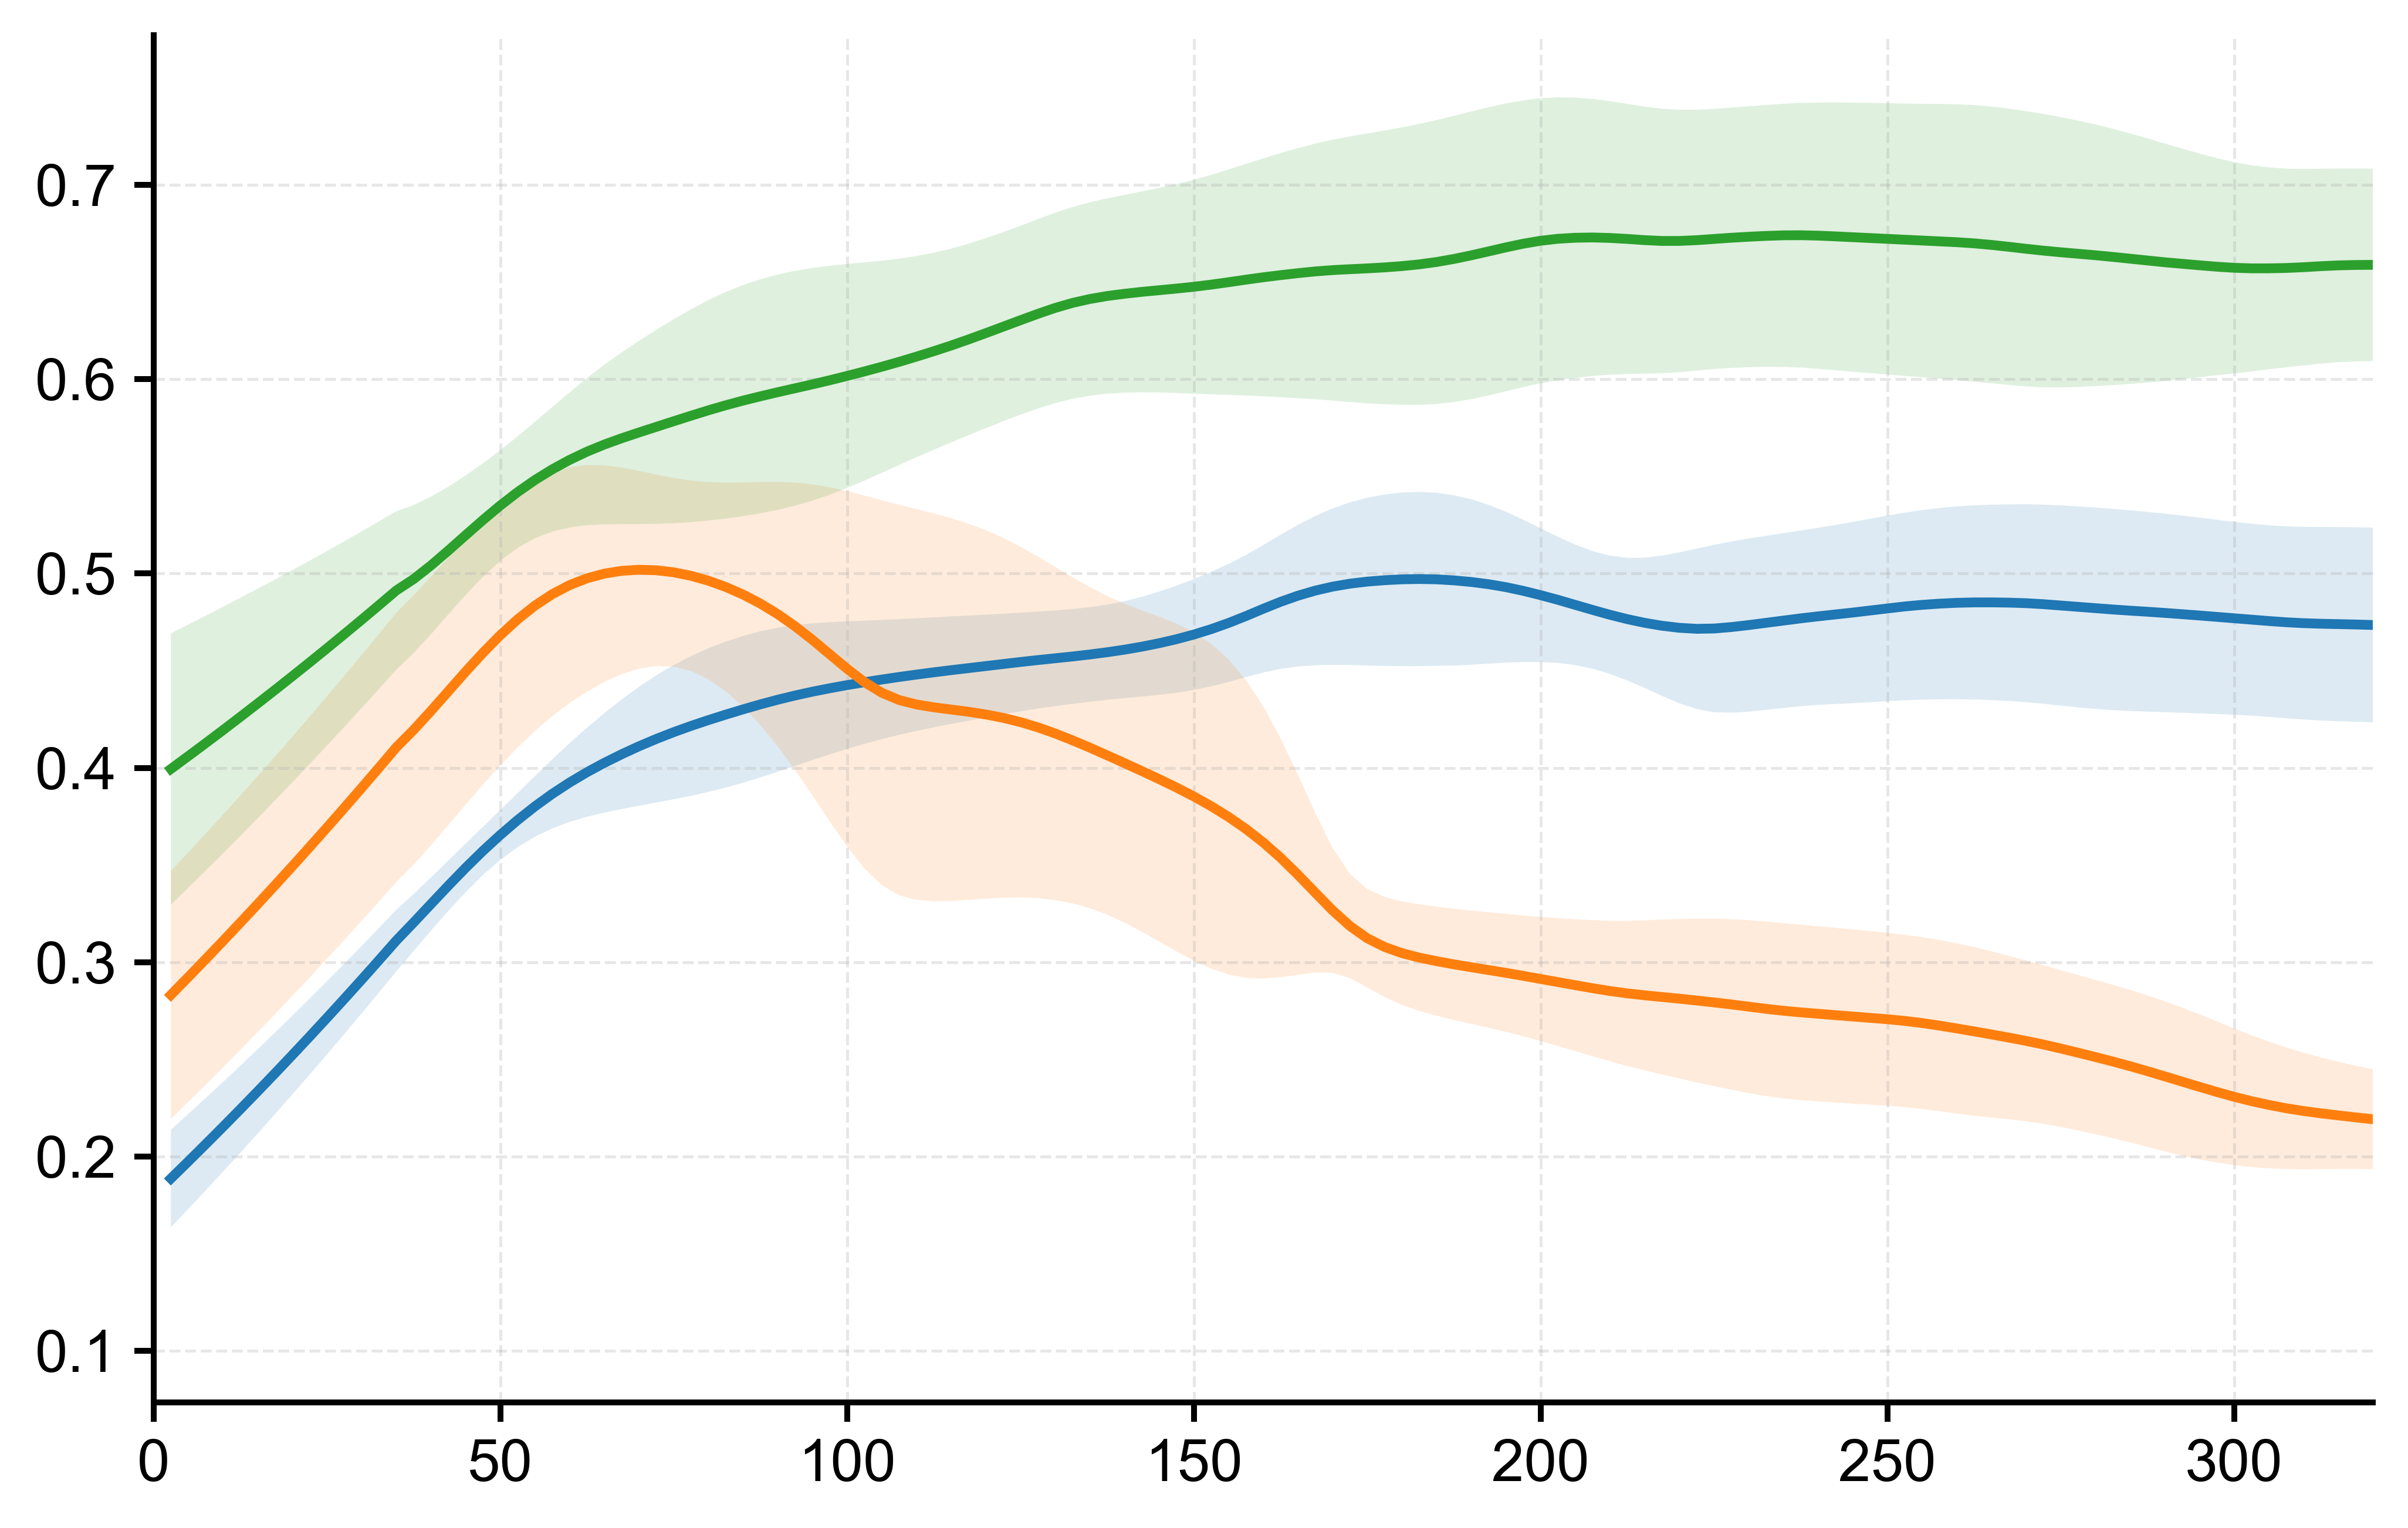

In [22]:
fig, ax = plt.subplots(figsize=(7, 4.5))

plot_stats = (
    results_1
    .groupby(["Gyr (U)", "TopoI (U)", "time_min","DNA Template", "[DNA] (nM)", "[RNAP] (nM)"])
    .agg(
        mean=("rate_corrected", "mean"),
        std=("rate_corrected", "std"),
        count=("rate_corrected", "count"),
    )
    .reset_index()
)

for (gyr, topoi), d in plot_stats.groupby(["Gyr (U)", "TopoI (U)"]):
    d = d.sort_values("time_min")
    x, y, sd = d["time_min"], d["mean"], d["std"]

    ax.plot(x, y, lw=2)
    ax.fill_between(x, y - sd, y + sd, alpha=0.15, lw=0)

ax.set_xlim(0, 320)
ax.grid(True, ls="--", lw=0.6, alpha=0.3)

ax.spines[["top", "right"]].set_visible(False)
ax.tick_params(direction="out", width=1.2, length=4)

save_path = Path("../figures/fig2_TX_analysis.pdf")
plt.savefig(save_path)

plt.tight_layout()
plt.show()

In [54]:
# ==============================================================================
# ANALYZE SELECTED WELLS
# ==============================================================================


df_2 = df[
    (df["Exp_ID"].isin(["TL39 TX44"])) &
    (df["Gyr (U)"] == 2)
].copy()

print("=== TRANSCRIPTION DATASET SUMMARY ===")
print(f"Selected rows       : {len(df_1)}")
print(f"Total experiments   : {df_1['Exp_ID'].nunique()}")
print(
    f"Total wells analyzed: "
    f"{df_1[['Exp_ID', 'Well']].drop_duplicates().shape[0]}"
)

blank_df_2 = df[
    (df["Exp_ID"].isin(["TL39 TX44"])) &
    (df["DNA Template"] == "BLANK")
].copy()



results_2 = analyze_wells(
    df=df_2,
    blank_df=blank_df_2,
    f_kernel=f_kernel,
    alpha_slope=alpha_slope,
    dt_min=DT_MIN,
    lambda_reg=LAMBDA_REG,
    window_min=WINDOW_MIN,
    polyorder=2,
    mode="interp",
)
print(results_1)

=== TRANSCRIPTION DATASET SUMMARY ===
Selected rows       : 1510
Total experiments   : 2
Total wells analyzed: 10
         Exp_ID Well  Cycle DNA Template  [DNA] (nM)  [RNAP] (nM)  Gyr (U)  \
0     TL39 TX46   F4      1   RX OPPO #2       0.068        340.0      0.0   
1     TL39 TX46   F4      2   RX OPPO #2       0.068        340.0      0.0   
2     TL39 TX46   F4      3   RX OPPO #2       0.068        340.0      0.0   
3     TL39 TX46   F4      4   RX OPPO #2       0.068        340.0      0.0   
4     TL39 TX46   F4      5   RX OPPO #2       0.068        340.0      0.0   
...         ...  ...    ...          ...         ...          ...      ...   
1505  TL39 TX47   D8    147   RX OPPO #2       0.068        340.0      2.0   
1506  TL39 TX47   D8    148   RX OPPO #2       0.068        340.0      2.0   
1507  TL39 TX47   D8    149   RX OPPO #2       0.068        340.0      2.0   
1508  TL39 TX47   D8    150   RX OPPO #2       0.068        340.0      2.0   
1509  TL39 TX47   D8    151 

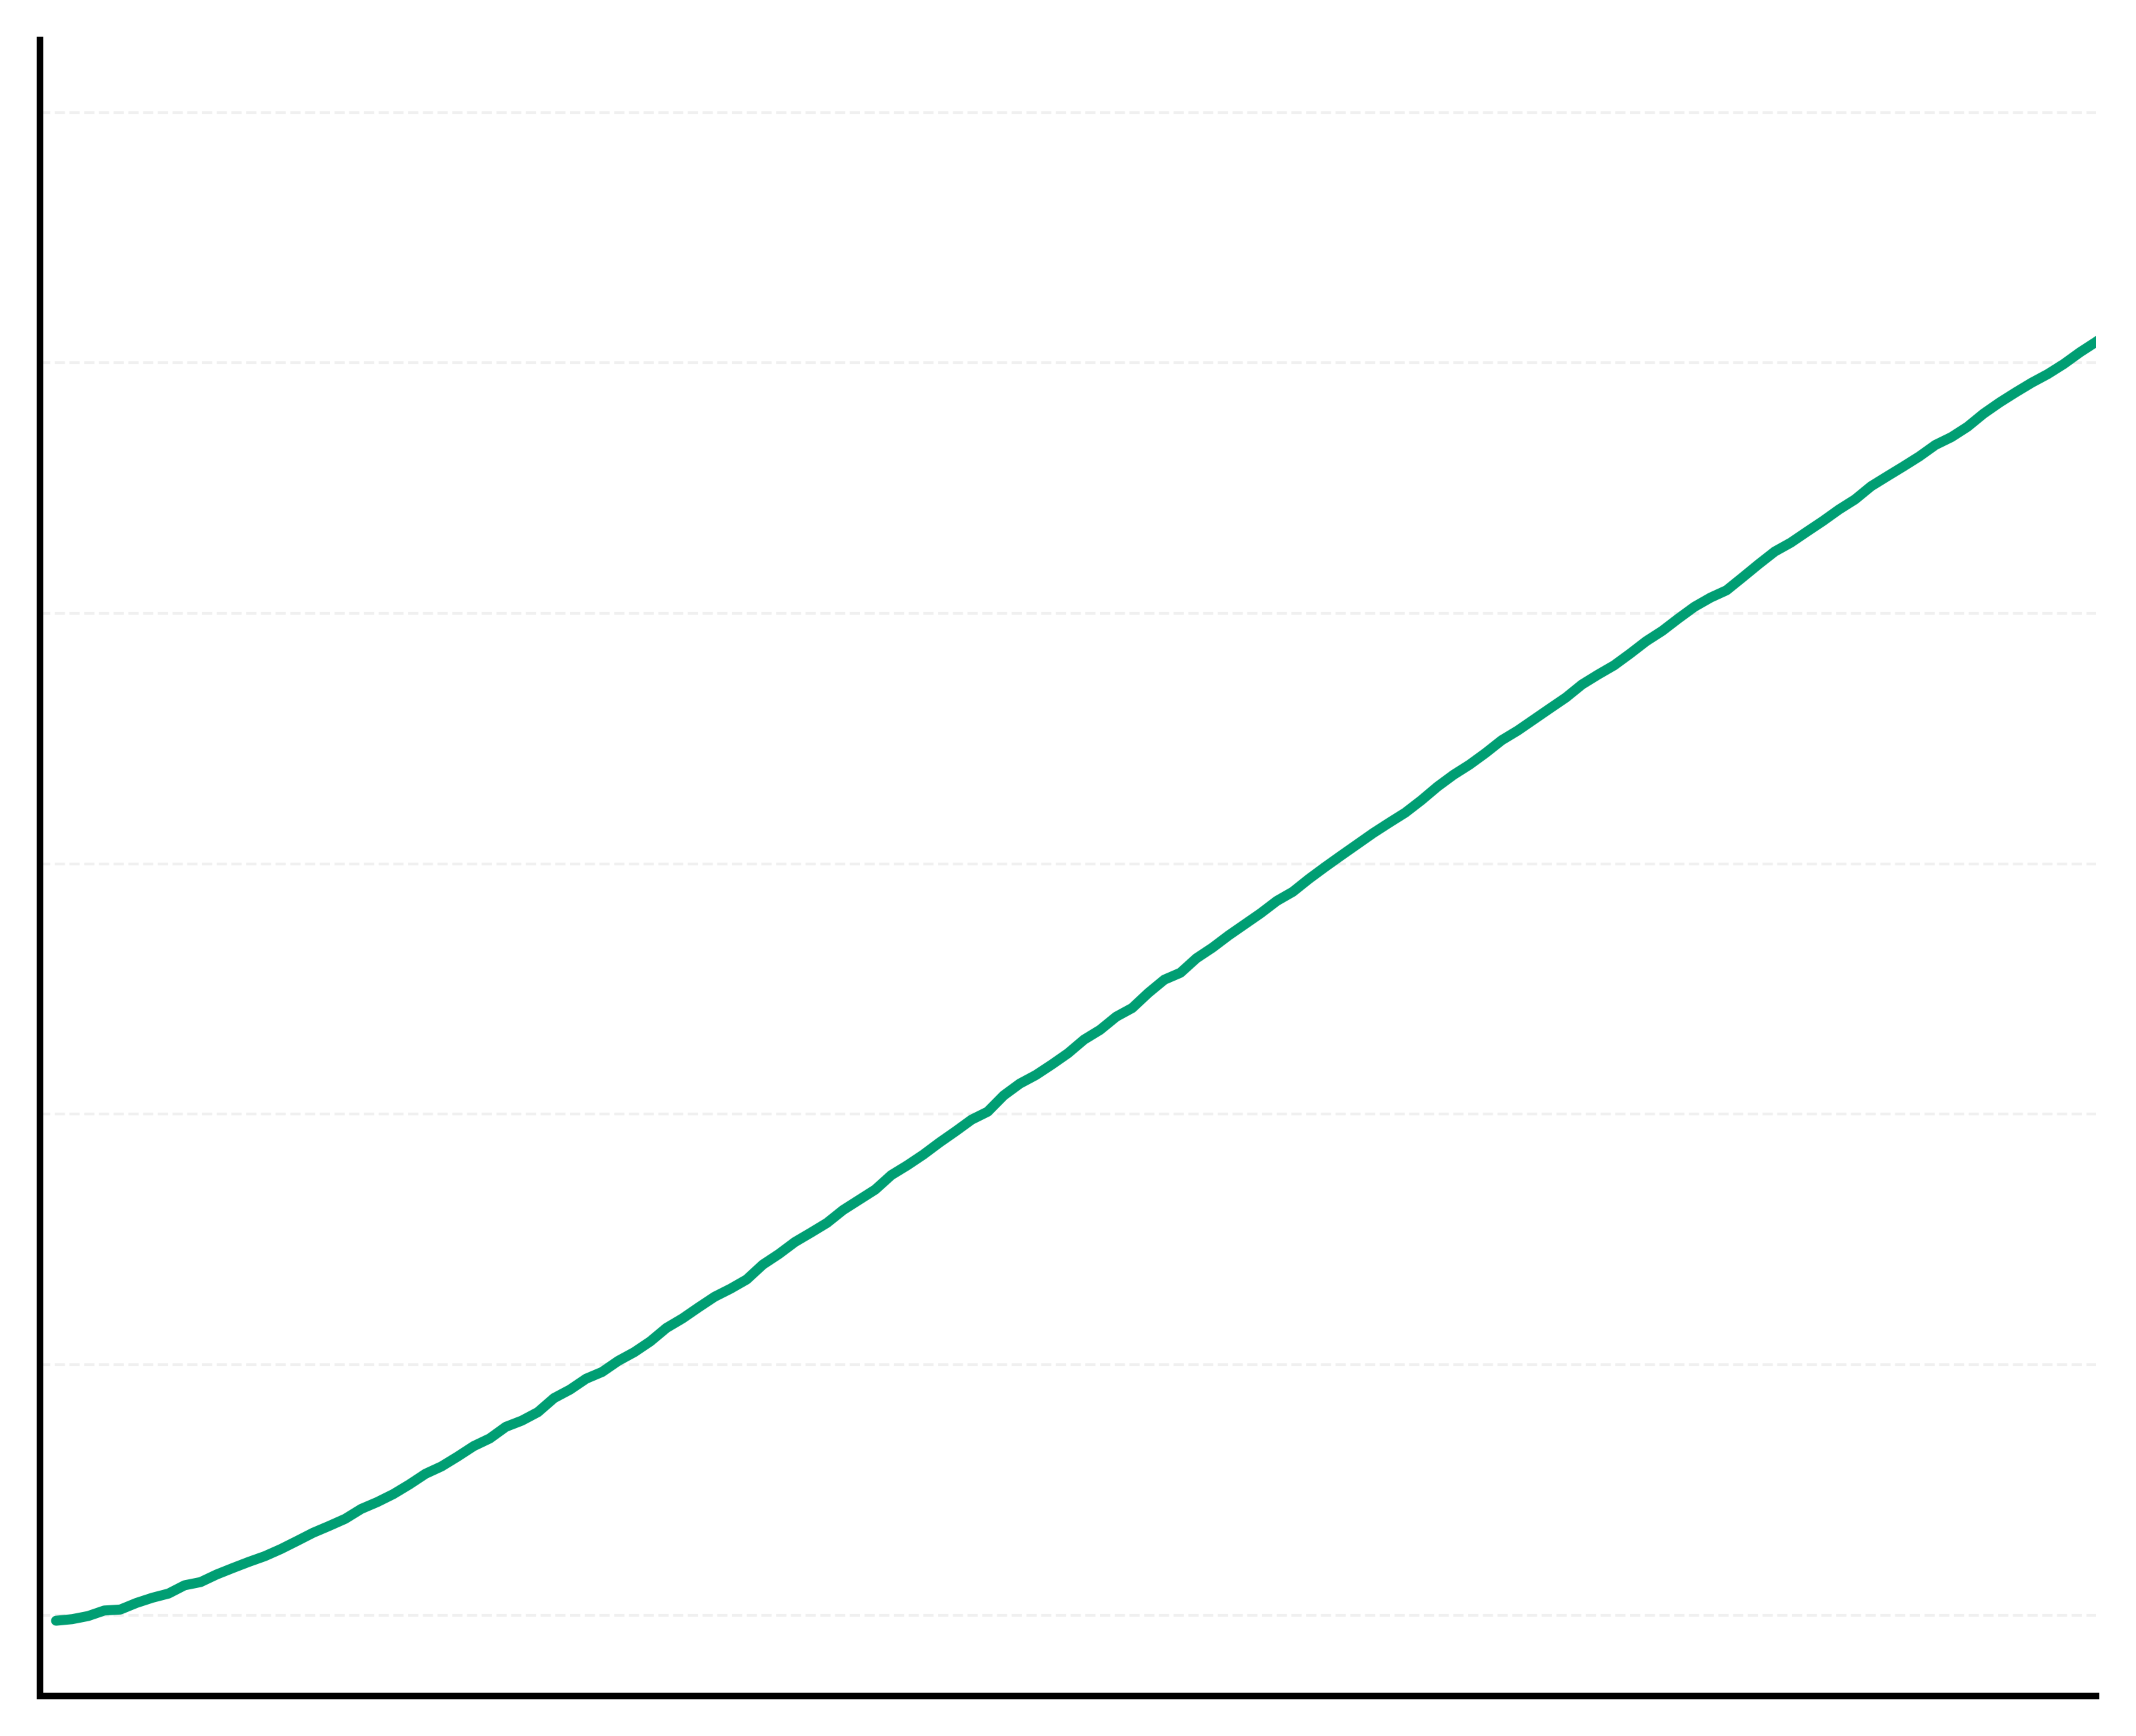

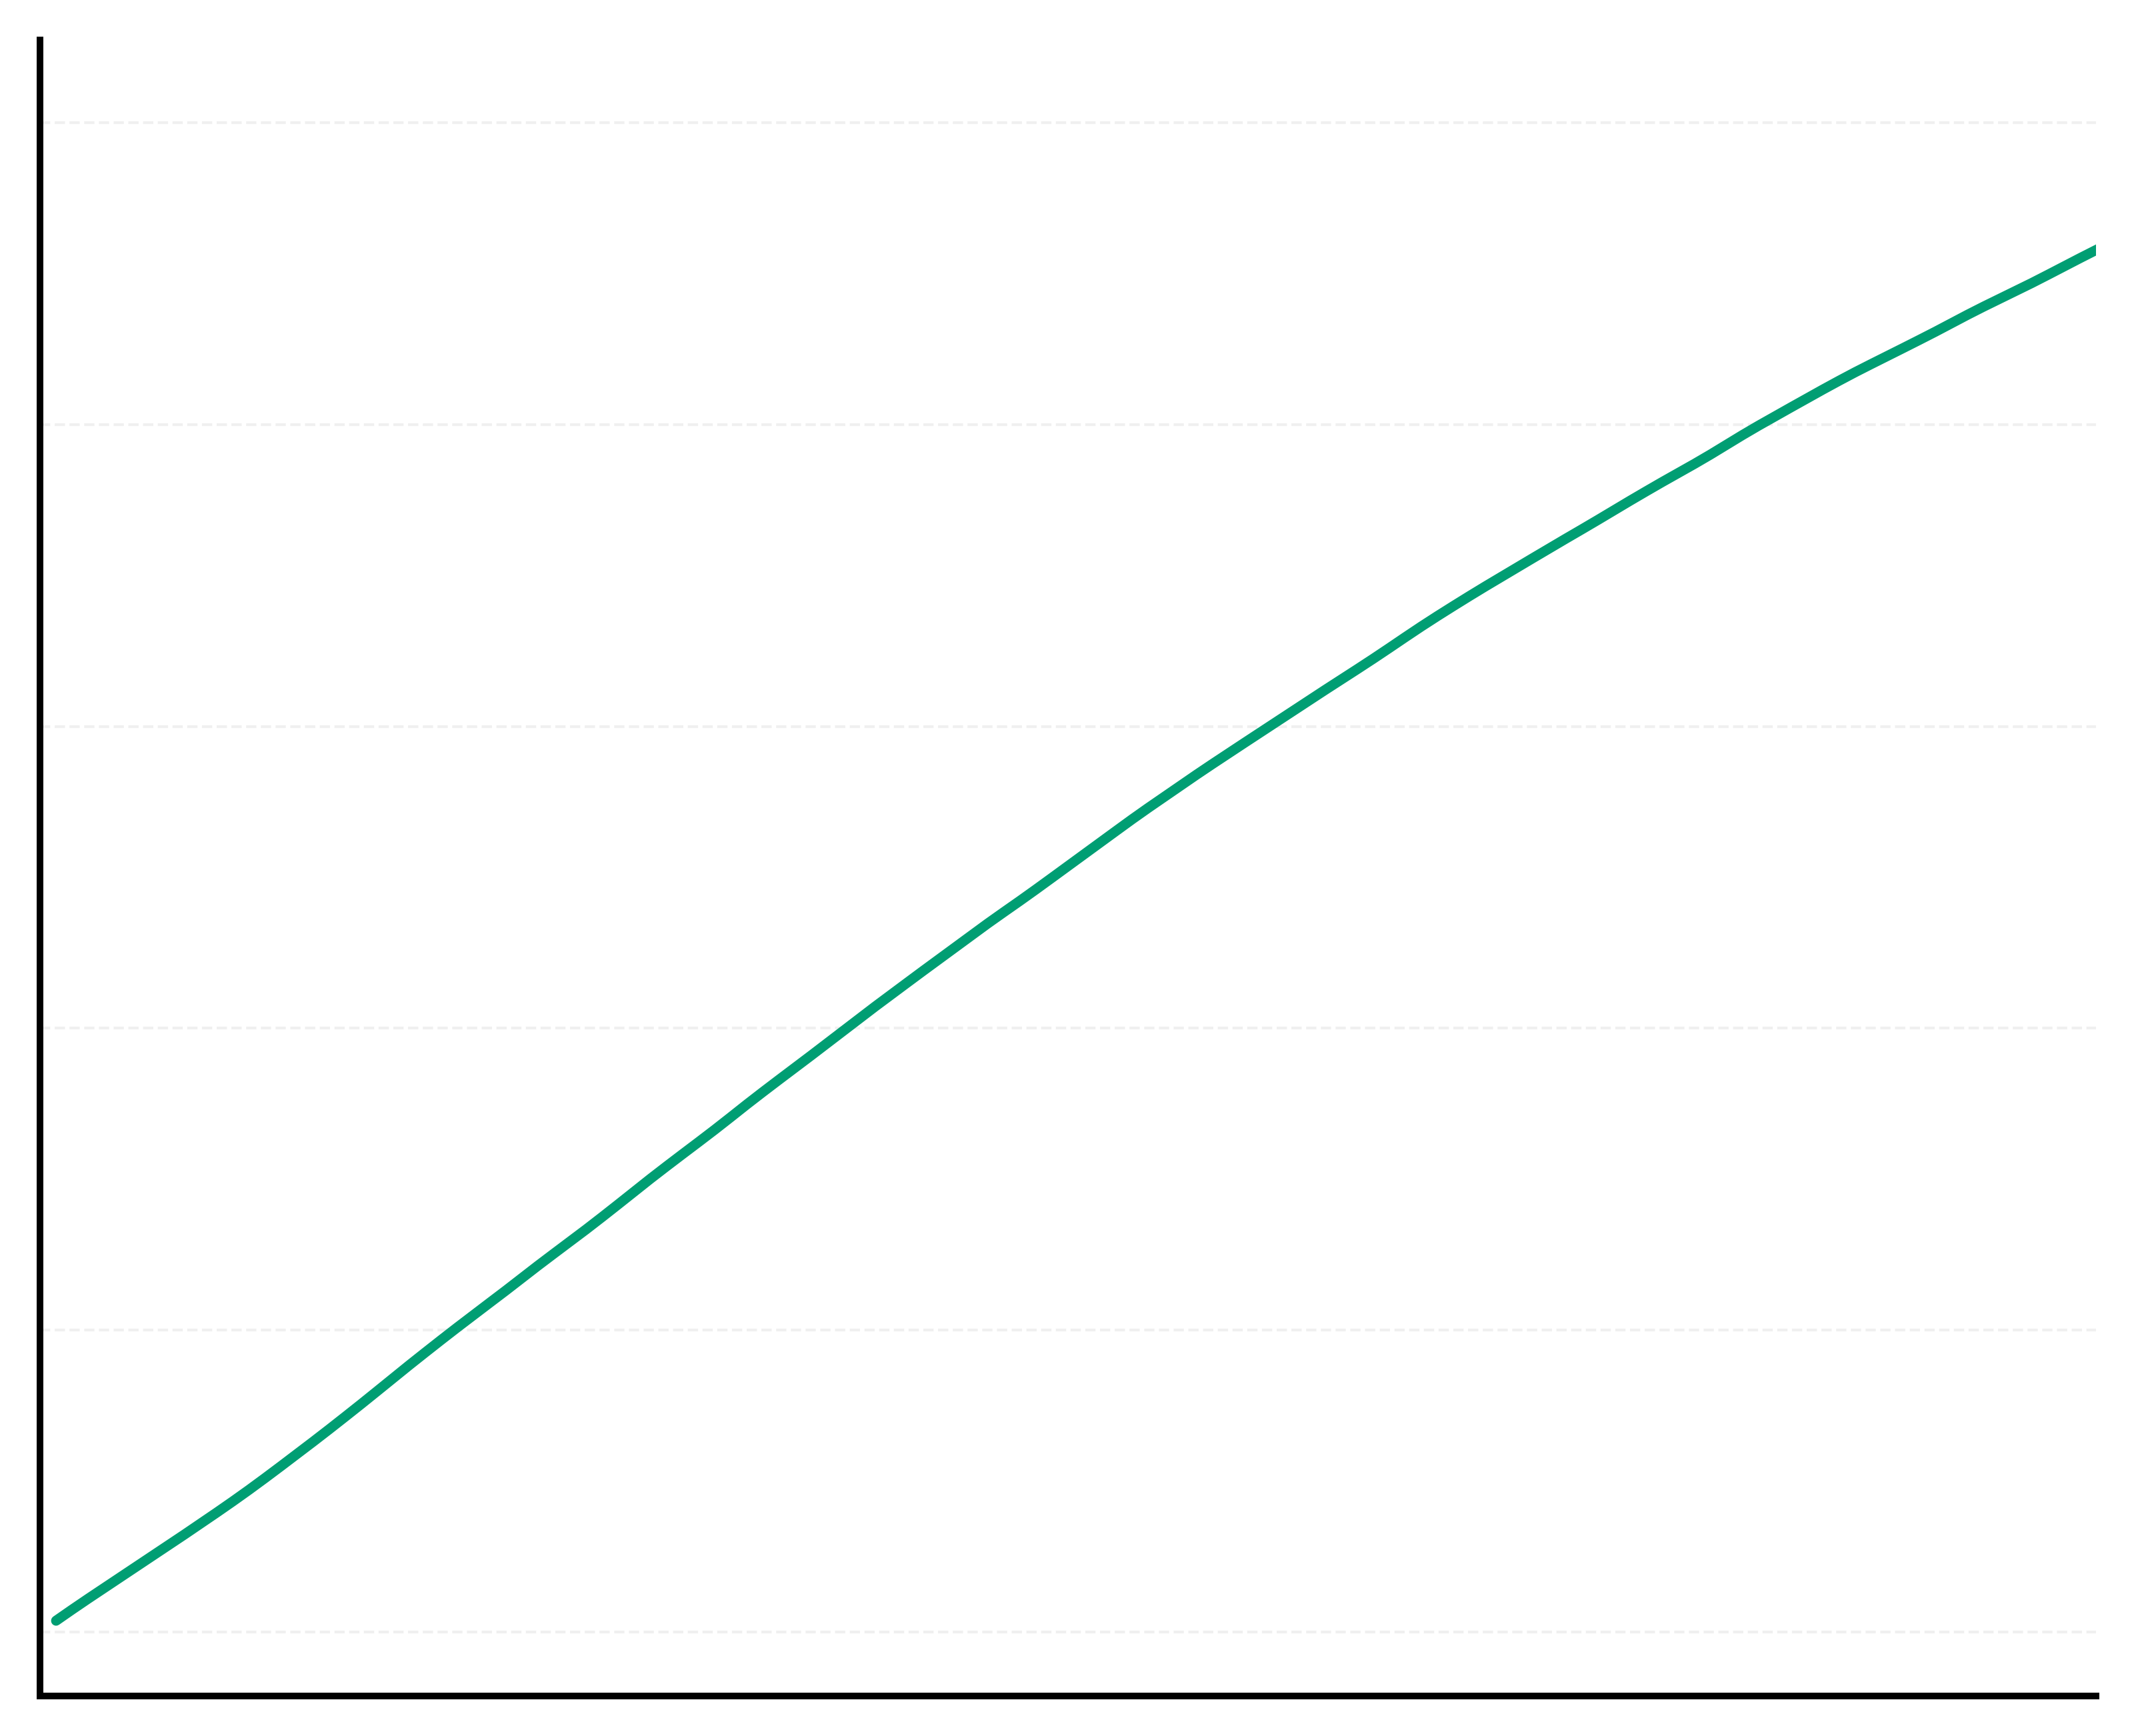

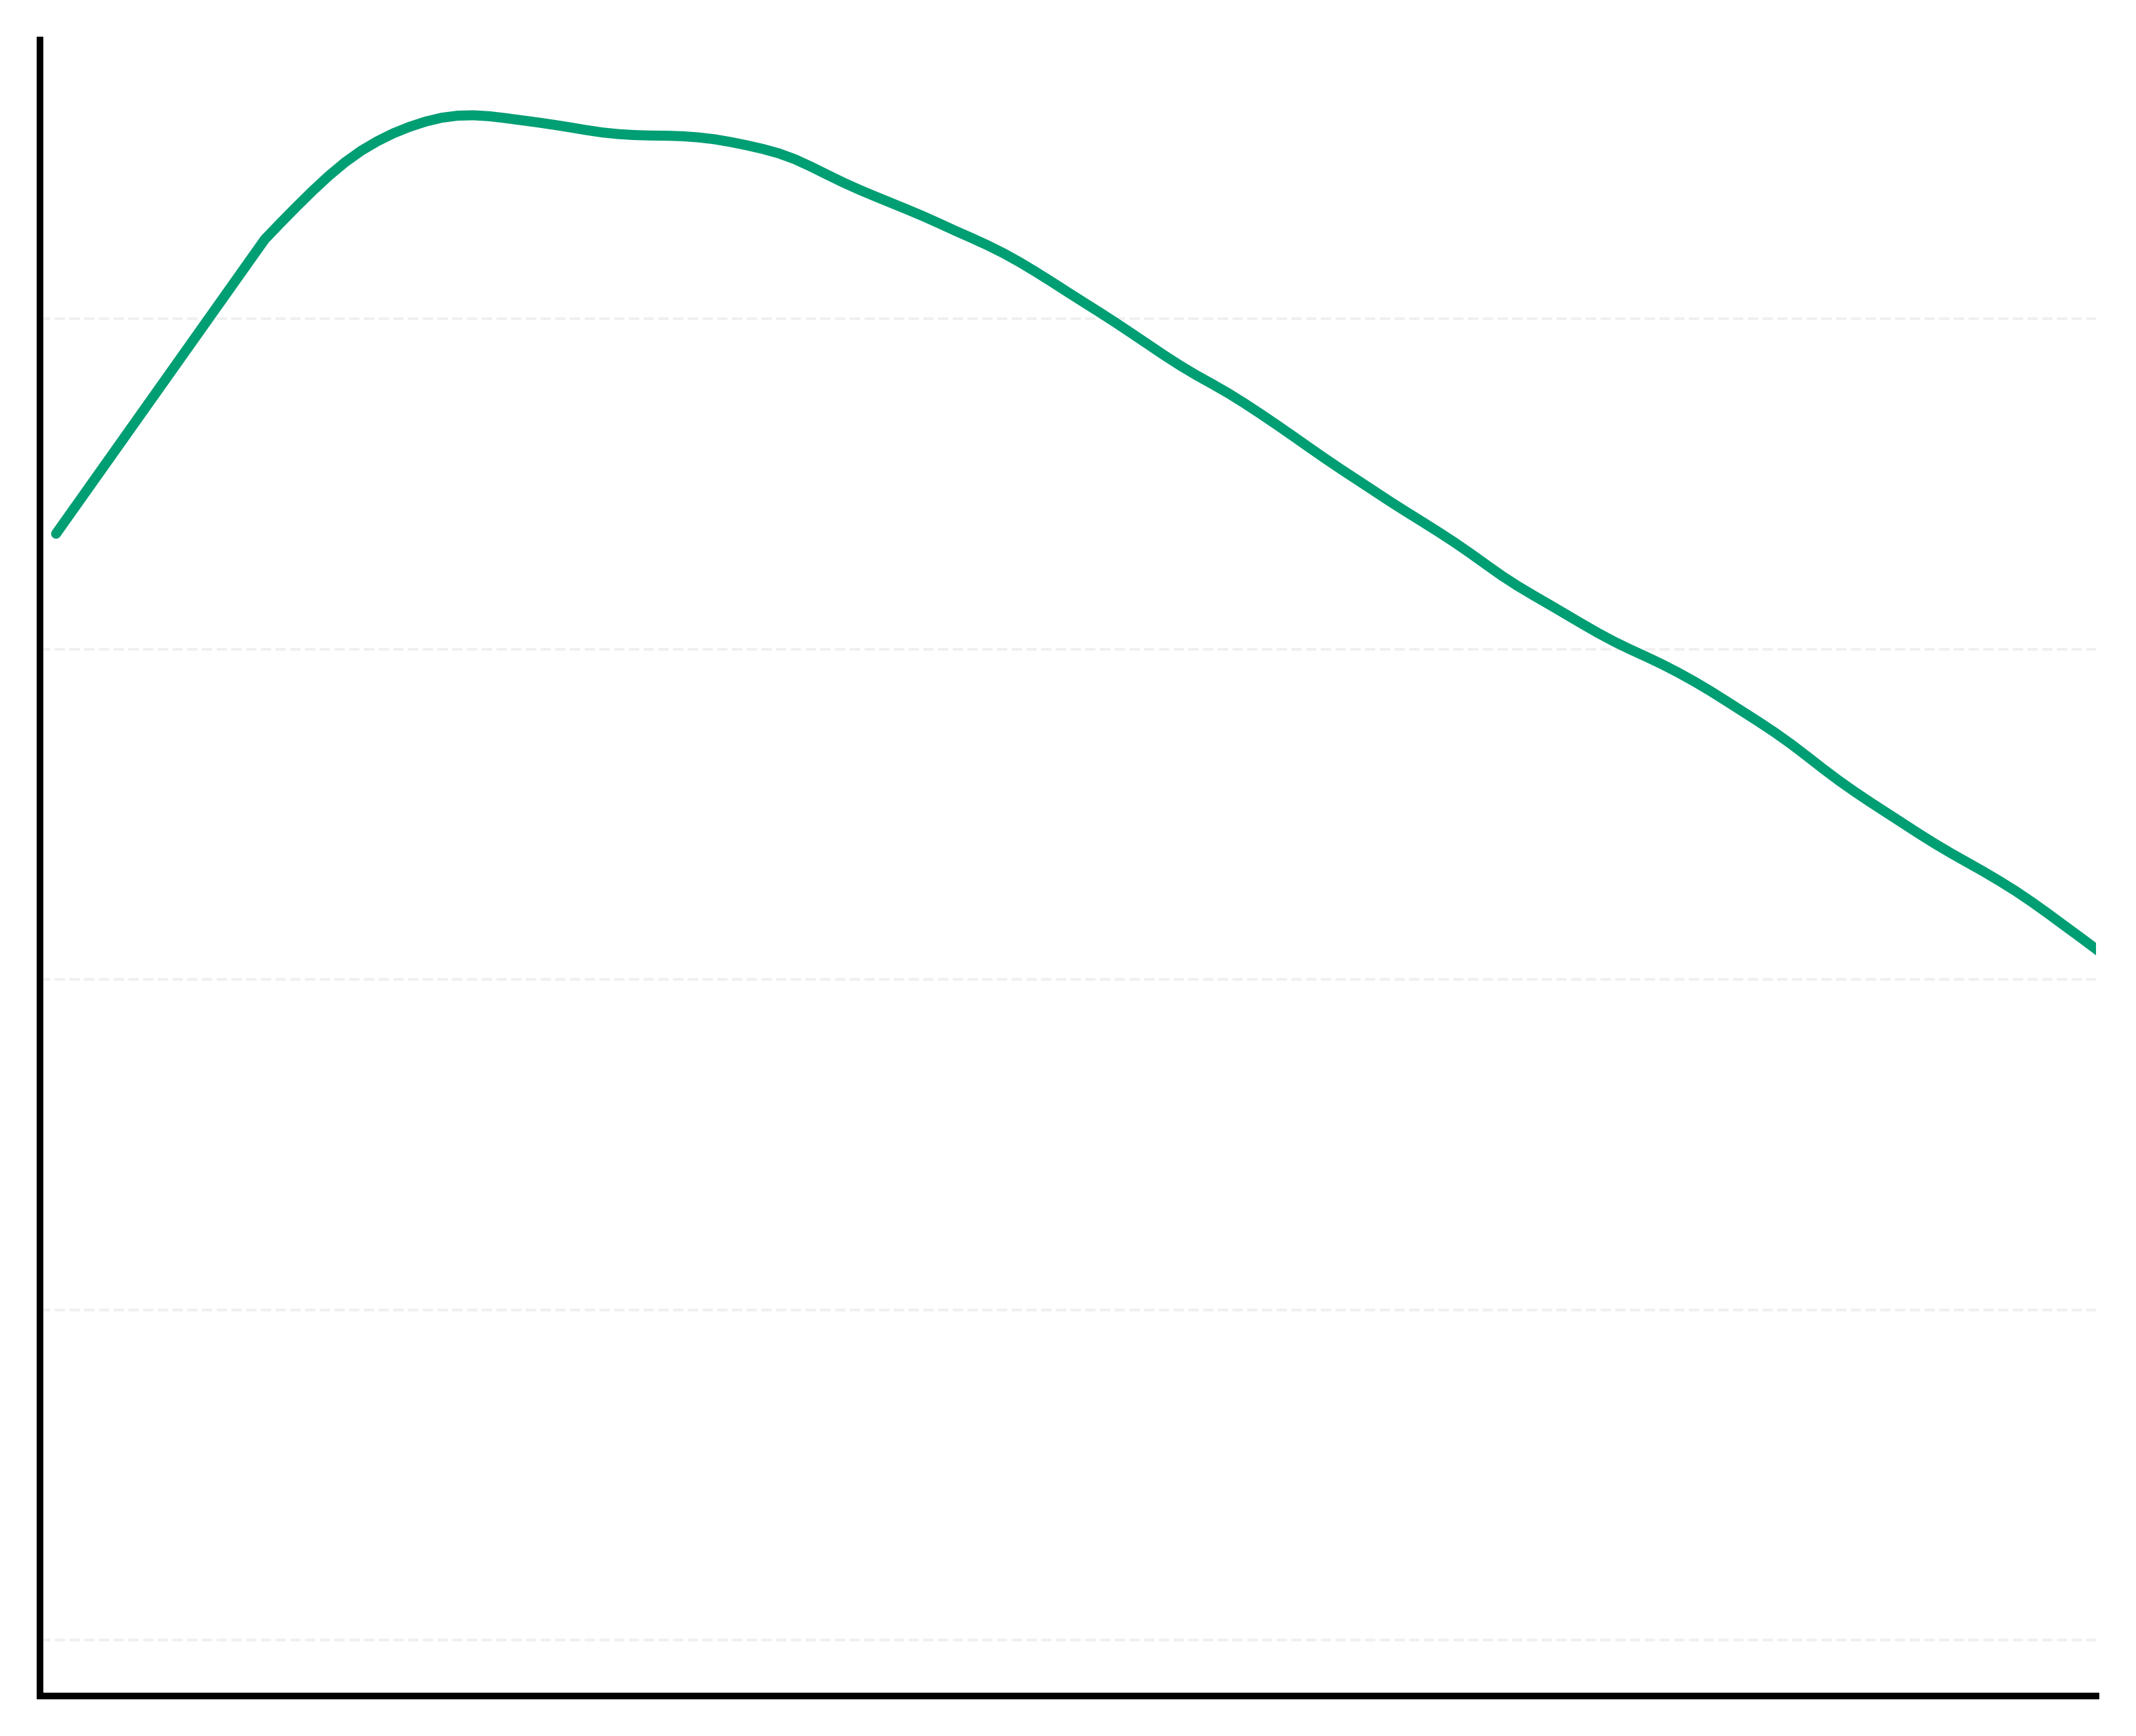

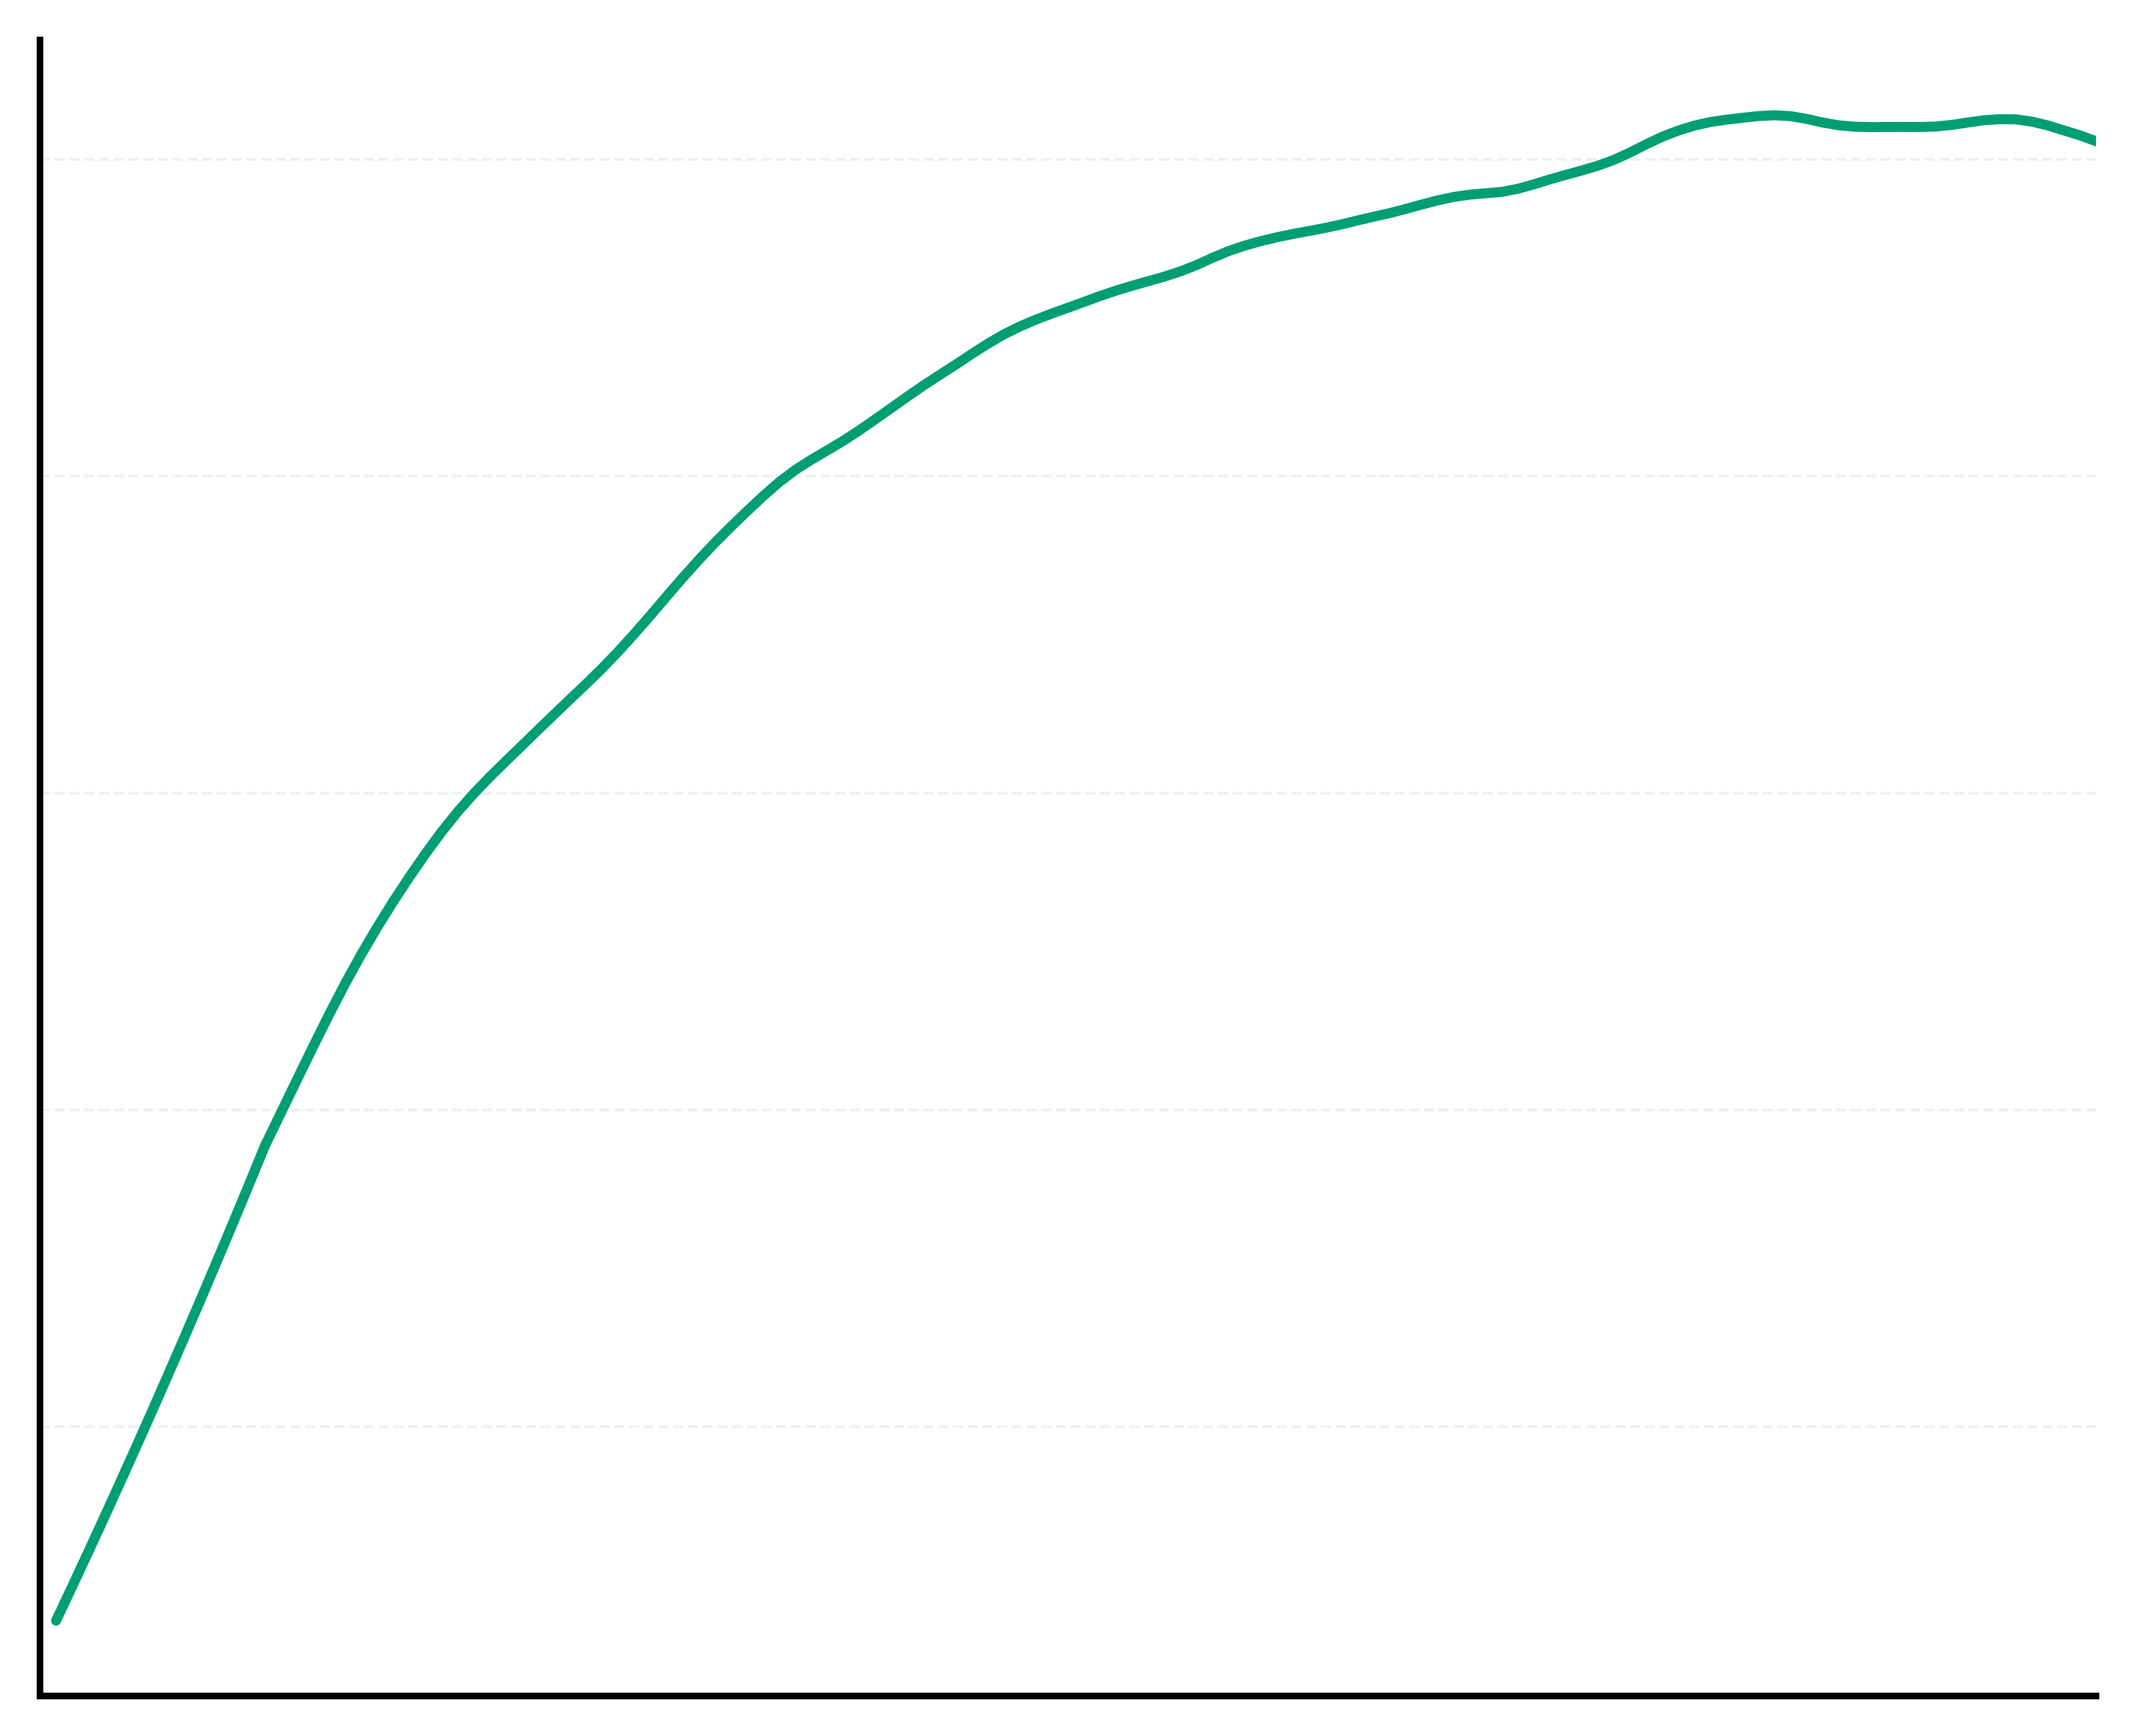

In [55]:
fig, ax = plt.subplots(figsize=(5.5, 4.5))

plot_stats = (
    results_2
    .groupby(["Gyr (U)", "TopoI (U)", "time_min","DNA Template", "[DNA] (nM)", "[RNAP] (nM)"])
    .agg(
        mean=("RFU_corrected", "mean"),
    )
    .reset_index()
)

colors = {
    (0, 0): "#0072B2",
    (2, 0): "#009E73",
    (0, 2): "#D55E00",
}

for (gyr, topoi), d in plot_stats.groupby(["Gyr (U)", "TopoI (U)"]):
    d = d.sort_values("time_min")
    x, y = d["time_min"], d["mean"]

    ax.plot(
        x,
        y,
        color=colors[(gyr, topoi)],
        lw=1.8,
        solid_capstyle="round",
    )


ax.set_xlim(0, 320)
ax.grid(axis="y", ls="--", lw=0.5, alpha=0.18)

ax.spines[["top", "right"]].set_visible(False)
ax.tick_params(axis="both", which="both", bottom=False, left=False, labelbottom=False, labelleft=False)
plt.tight_layout()

save_path = Path("../figures/fig1_raw_kinectis.pdf")
plt.savefig(save_path)

plt.show()

##

fig1, ax1 = plt.subplots(figsize=(5.5, 4.5))

plot_stats = (
    results_2
    .groupby(["Gyr (U)", "TopoI (U)", "time_min","DNA Template", "[DNA] (nM)", "[RNAP] (nM)"])
    .agg(
        mean=("RNA_cumulated", "mean"),
    )
    .reset_index()
)

for (gyr, topoi), d in plot_stats.groupby(["Gyr (U)", "TopoI (U)"]):
    d = d.sort_values("time_min")
    x, y = d["time_min"], d["mean"]

    ax1.plot(
        x,
        y,
        color=colors[(gyr, topoi)],
        lw=1.8,
        solid_capstyle="round",
    )


ax1.set_xlim(0, 320)
ax1.grid(axis="y", ls="--", lw=0.5, alpha=0.18)

ax1.spines[["top", "right"]].set_visible(False)
ax1.tick_params(axis="both", which="both", bottom=False, left=False, labelbottom=False, labelleft=False)

plt.tight_layout()

save_path = Path("../figures/fig1_deconvoluted.pdf")
plt.savefig(save_path)

plt.show()

##

fig1, ax1 = plt.subplots(figsize=(5.5, 4.5))

plot_stats = (
    results_2
    .groupby(["Gyr (U)", "TopoI (U)", "time_min","DNA Template", "[DNA] (nM)", "[RNAP] (nM)"])
    .agg(
        mean=("rate_instantaneous", "mean"),
    )
    .reset_index()
)

for (gyr, topoi), d in plot_stats.groupby(["Gyr (U)", "TopoI (U)"]):
    d = d.sort_values("time_min")
    x, y = d["time_min"], d["mean"]

    ax1.plot(
        x,
        y,
        color=colors[(gyr, topoi)],
        lw=1.8,
        solid_capstyle="round",
    )


ax1.set_xlim(0, 320)
ax1.grid(axis="y", ls="--", lw=0.5, alpha=0.18)

ax1.spines[["top", "right"]].set_visible(False)
ax1.tick_params(axis="both", which="both", bottom=False, left=False, labelbottom=False, labelleft=False)

plt.tight_layout()

save_path = Path("../figures/fig1_rate.pdf")
plt.savefig(save_path)

plt.show()

##

fig1, ax1 = plt.subplots(figsize=(5.5, 4.5))

plot_stats = (
    results_2
    .groupby(["Gyr (U)", "TopoI (U)", "time_min","DNA Template", "[DNA] (nM)", "[RNAP] (nM)"])
    .agg(
        mean=("rate_corrected", "mean"),
    )
    .reset_index()
)

for (gyr, topoi), d in plot_stats.groupby(["Gyr (U)", "TopoI (U)"]):
    d = d.sort_values("time_min")
    x, y = d["time_min"], d["mean"]

    ax1.plot(
        x,
        y,
        color=colors[(gyr, topoi)],
        lw=1.8,
        solid_capstyle="round",
    )


ax1.set_xlim(0, 320)
ax1.grid(axis="y", ls="--", lw=0.5, alpha=0.18)

ax1.spines[["top", "right"]].set_visible(False)
ax1.tick_params(axis="both", which="both", bottom=False, left=False, labelbottom=False, labelleft=False)

plt.tight_layout()

save_path = Path("../figures/fig1_corrected_rate.pdf")
plt.savefig(save_path)

plt.show()

## Figure 3: ≠ [Topoisomerases] effects on circular relaxed plasmid

### 1. Load datas from TX44 



In [ ]:
# ------------------------------------------------------------------------------

df_3_gyr = df[
    (df["Exp_ID"].isin(["TL39 TX44"])) &
    (df["TopoI (U)"] == 0) &
    (df["DNA Template"].str.contains("RX", na=False))
].copy()

print("=== TRANSCRIPTION DATASET SUMMARY ===")
print(f"Selected rows       : {len(df_3_gyr)}")
print(f"Total experiments   : {df_3_gyr['Exp_ID'].nunique()}")
print(
    f"Total wells analyzed: "
    f"{df_3_gyr[['Exp_ID', 'Well']].drop_duplicates().shape[0]}"
)



df_3_topo = df[
    (df["Exp_ID"].isin(["TL39 TX44"])) &
    (df["Gyr (U)"] == 0) &
    (df["DNA Template"].str.contains("RX", na=False))
].copy()

print("=== TRANSCRIPTION DATASET SUMMARY ===")
print(f"Selected rows       : {len(df_3_topo)}")
print(f"Total experiments   : {df_3_topo['Exp_ID'].nunique()}")
print(
    f"Total wells analyzed: "
    f"{df_3_topo[['Exp_ID', 'Well']].drop_duplicates().shape[0]}"
)


blank_df_3 = df[
    (df["Exp_ID"].isin(["TL39 TX44"])) &
    (df["DNA Template"] == "BLANK")
].copy()

=== TRANSCRIPTION DATASET SUMMARY ===
Selected rows       : 906
Total experiments   : 1
Total wells analyzed: 6
=== TRANSCRIPTION DATASET SUMMARY ===
Selected rows       : 1057
Total experiments   : 1
Total wells analyzed: 7


### 2. Deconvolution + rate computation + inactivation correction 


In [57]:
# ==============================================================================
# ANALYZE SELECTED WELLS
# ==============================================================================

results_3_gyr = analyze_wells(
    df=df_3_gyr,
    blank_df=blank_df_3,
    f_kernel=f_kernel,
    alpha_slope=alpha_slope,
    dt_min=DT_MIN,
    lambda_reg=LAMBDA_REG,
    window_min=WINDOW_MIN,
    polyorder=2,
    mode="interp",
)
print(results_3_gyr)



results_3_topo = analyze_wells(
    df=df_3_topo,
    blank_df=blank_df_3,
    f_kernel=f_kernel,
    alpha_slope=alpha_slope,
    dt_min=DT_MIN,
    lambda_reg=LAMBDA_REG,
    window_min=WINDOW_MIN,
    polyorder=2,
    mode="interp",
)
print(results_3_topo)


        Exp_ID Well  Cycle DNA Template  [DNA] (nM)  [RNAP] (nM)  Gyr (U)  \
0    TL39 TX44   B4      1   RX OPPO #2      0.0534        267.0     16.0   
1    TL39 TX44   B4      2   RX OPPO #2      0.0534        267.0     16.0   
2    TL39 TX44   B4      3   RX OPPO #2      0.0534        267.0     16.0   
3    TL39 TX44   B4      4   RX OPPO #2      0.0534        267.0     16.0   
4    TL39 TX44   B4      5   RX OPPO #2      0.0534        267.0     16.0   
..         ...  ...    ...          ...         ...          ...      ...   
901  TL39 TX44  B16    147   RX OPPO #2      0.0534        267.0      0.0   
902  TL39 TX44  B16    148   RX OPPO #2      0.0534        267.0      0.0   
903  TL39 TX44  B16    149   RX OPPO #2      0.0534        267.0      0.0   
904  TL39 TX44  B16    150   RX OPPO #2      0.0534        267.0      0.0   
905  TL39 TX44  B16    151   RX OPPO #2      0.0534        267.0      0.0   

     TopoI (U)  time_min      RFU_raw    RFU_blank  RFU_corrected  \
0     

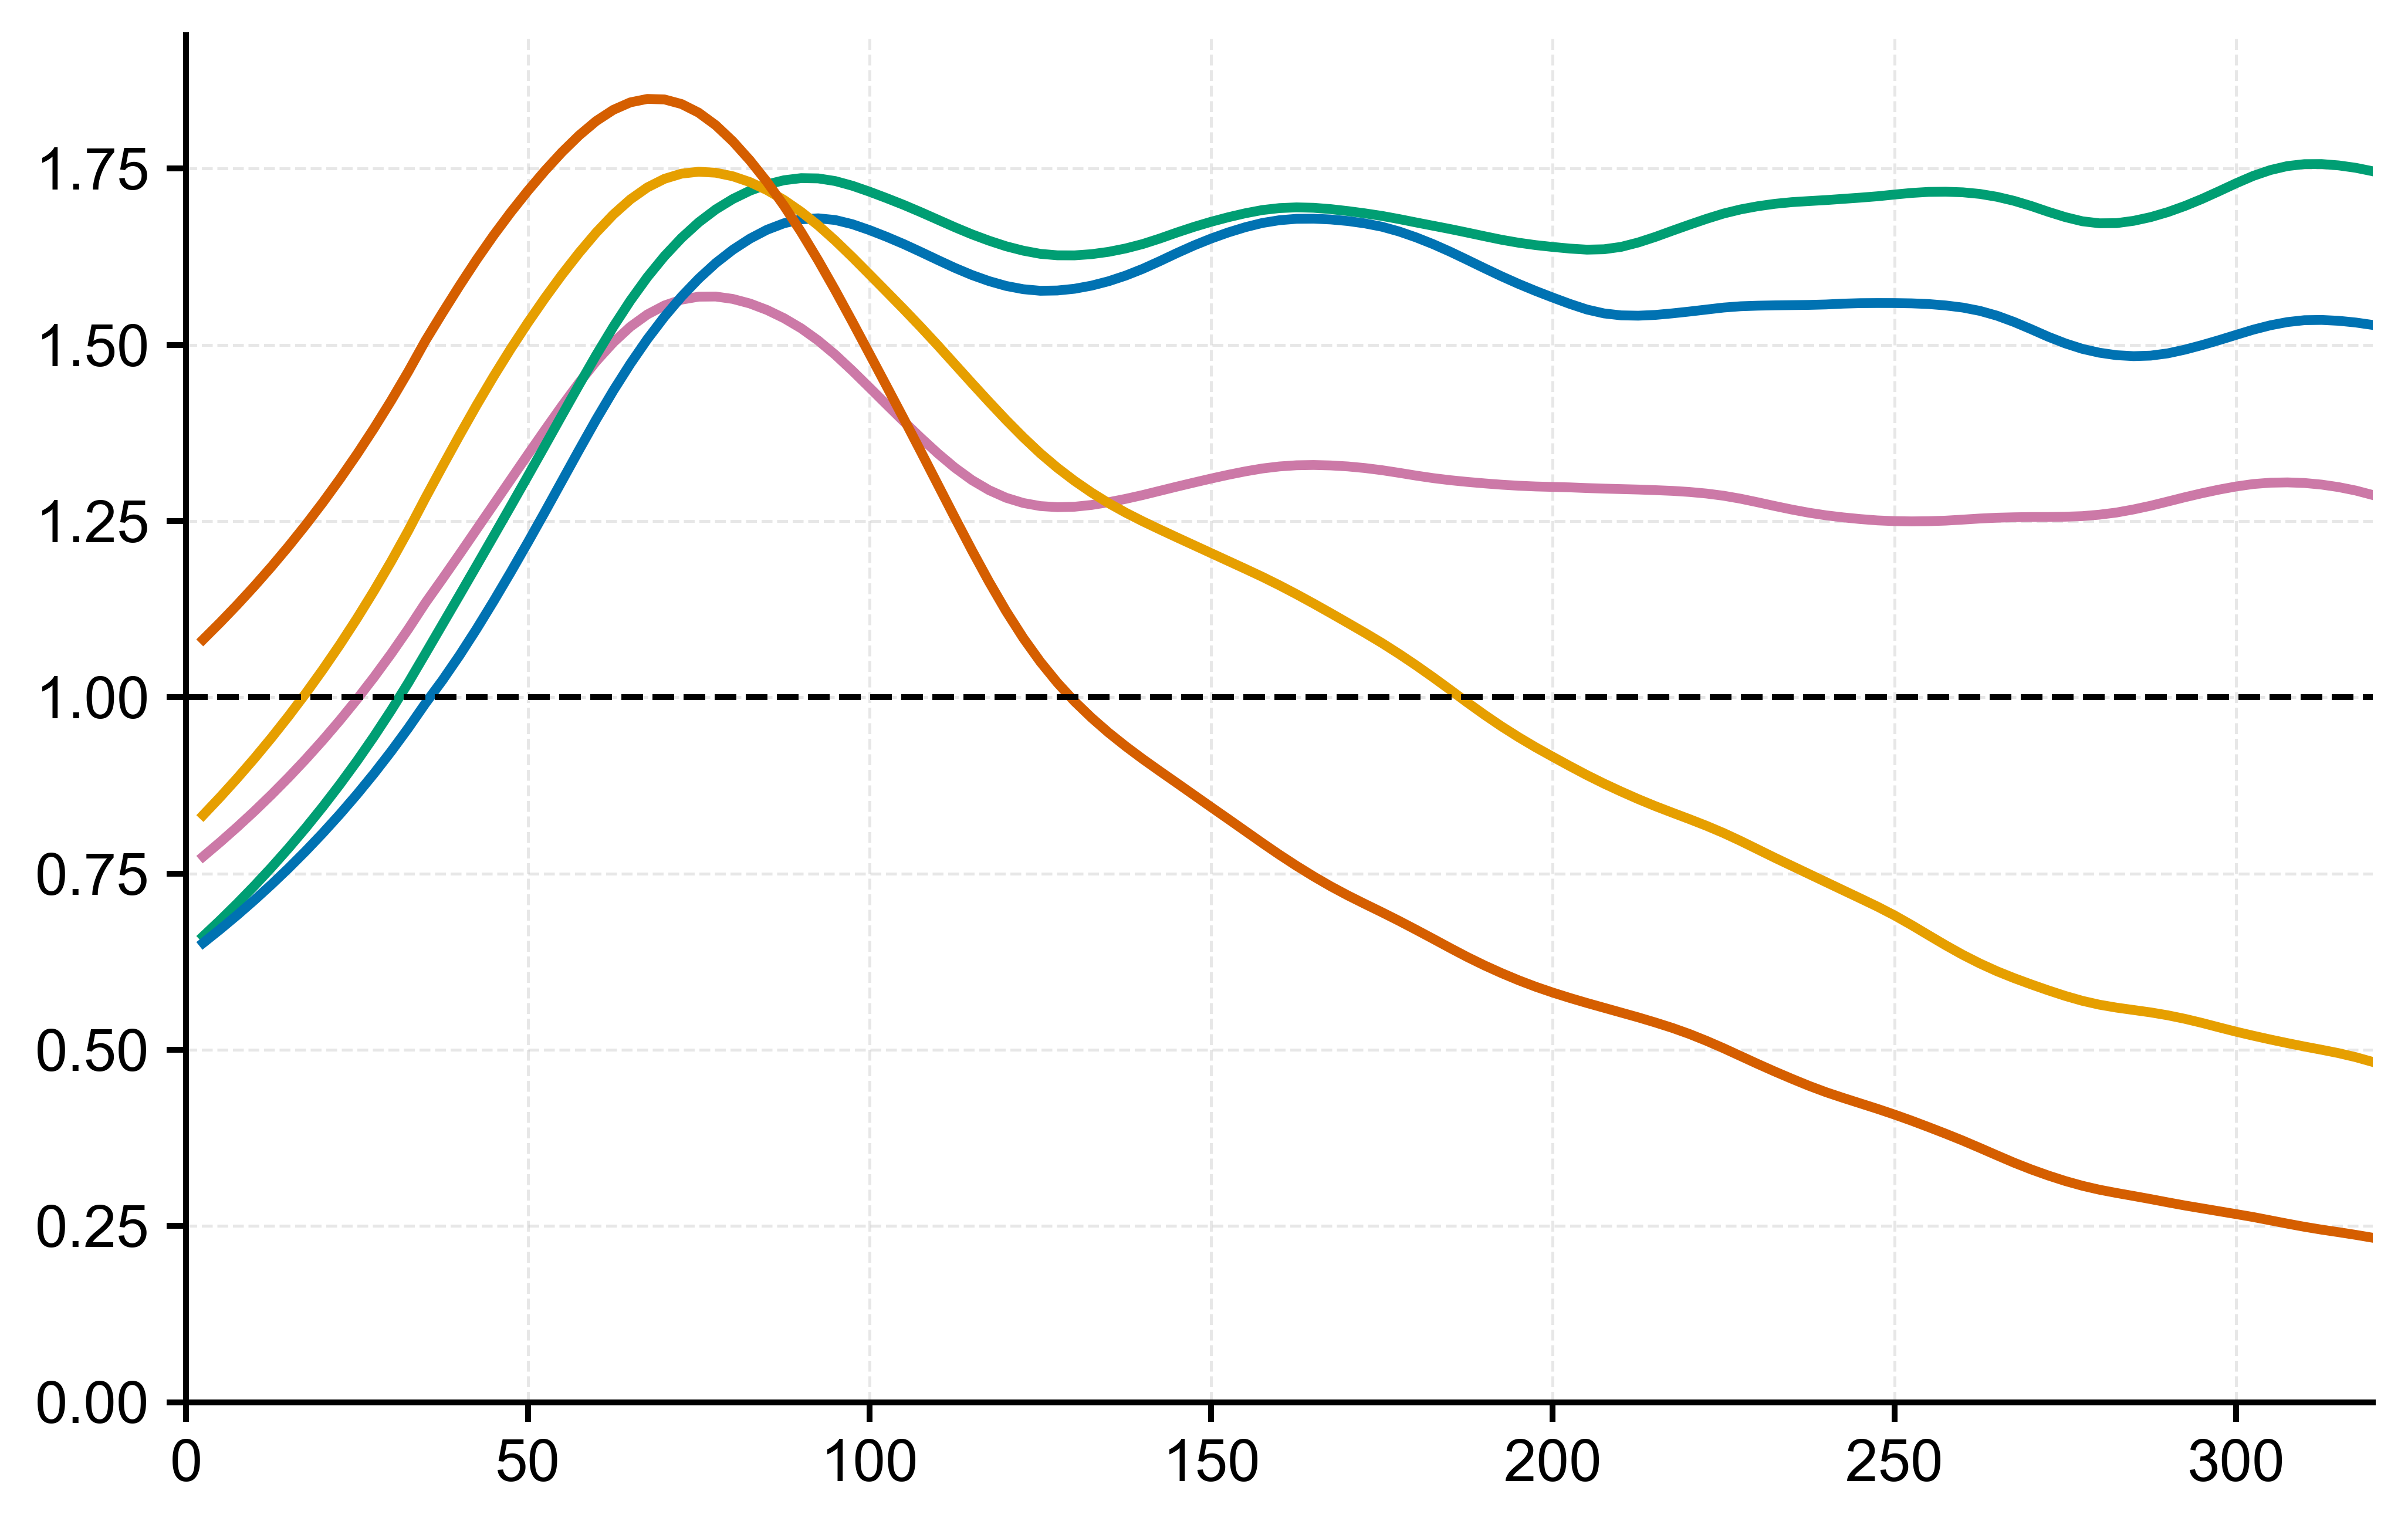

In [58]:
fig, ax = plt.subplots(figsize=(7, 4.5))

plot_stats = (
    results_3_gyr
    .groupby(["Gyr (U)", "TopoI (U)", "time_min", "DNA Template", "[DNA] (nM)", "[RNAP] (nM)"])
    .agg(
        mean=("rate_corrected", "mean"),
        std=("rate_corrected", "std"),
        count=("rate_corrected", "count"),
    )
    .reset_index()
)

# Baseline = 0 U Gyrase
baseline = (
    plot_stats[plot_stats["Gyr (U)"] == 0]
    [["TopoI (U)", "time_min", "mean"]]
    .rename(columns={"mean": "baseline"})
)

# Fold change vs 0 U Gyrase
plot_stats = plot_stats.merge(
    baseline,
    on=["TopoI (U)", "time_min"],
    how="left",
)

plot_stats["fold_change"] = plot_stats["mean"] / plot_stats["baseline"]
plot_stats["fold_change_std"] = plot_stats["std"] / plot_stats["baseline"]

# Plot only conditions with gyrase
#colors = {
#    0.5: "#B8D8C0",
#    2.0: "#009E73",
#   4.0: "#5AAE61",
#    8.0: "#238B45",
#    16.0: "#005A32",
#}

colors = {
    0.5: "#CC79A7",   # violet
    2.0: "#009E73",   # vert — même que Figure 1
    4.0: "#0072B2",   # bleu
    8.0: "#E69F00",   # jaune/orange
    16.0: "#D55E00",  # orange
}

for (gyr, topoi), d in plot_stats[plot_stats["Gyr (U)"] != 0].groupby(
    ["Gyr (U)", "TopoI (U)"]
):
    d = d.sort_values("time_min")
    x = d["time_min"]
    y = d["fold_change"]
    sd = d["fold_change_std"]

    ax.plot(
        x,
        y,
        color=colors[gyr],
        lw=2,
    )

    ax.fill_between(
        x,
        y - sd,
        y + sd,
        color=colors[gyr],
        alpha=0.15,
        lw=0,
    )

# Baseline
ax.axhline(1, color="black", ls="--", lw=1.2)

ax.set_xlim(0, 320)
ax.set_ylim(0, None)
ax.grid(True, ls="--", lw=0.6, alpha=0.3)

ax.spines[["top", "right"]].set_visible(False)
ax.tick_params(direction="out", width=1.2, length=4)

save_path = Path("../figures/fig3_gyrase_TX_analysis.pdf")
plt.savefig(save_path)

plt.tight_layout()
plt.show()

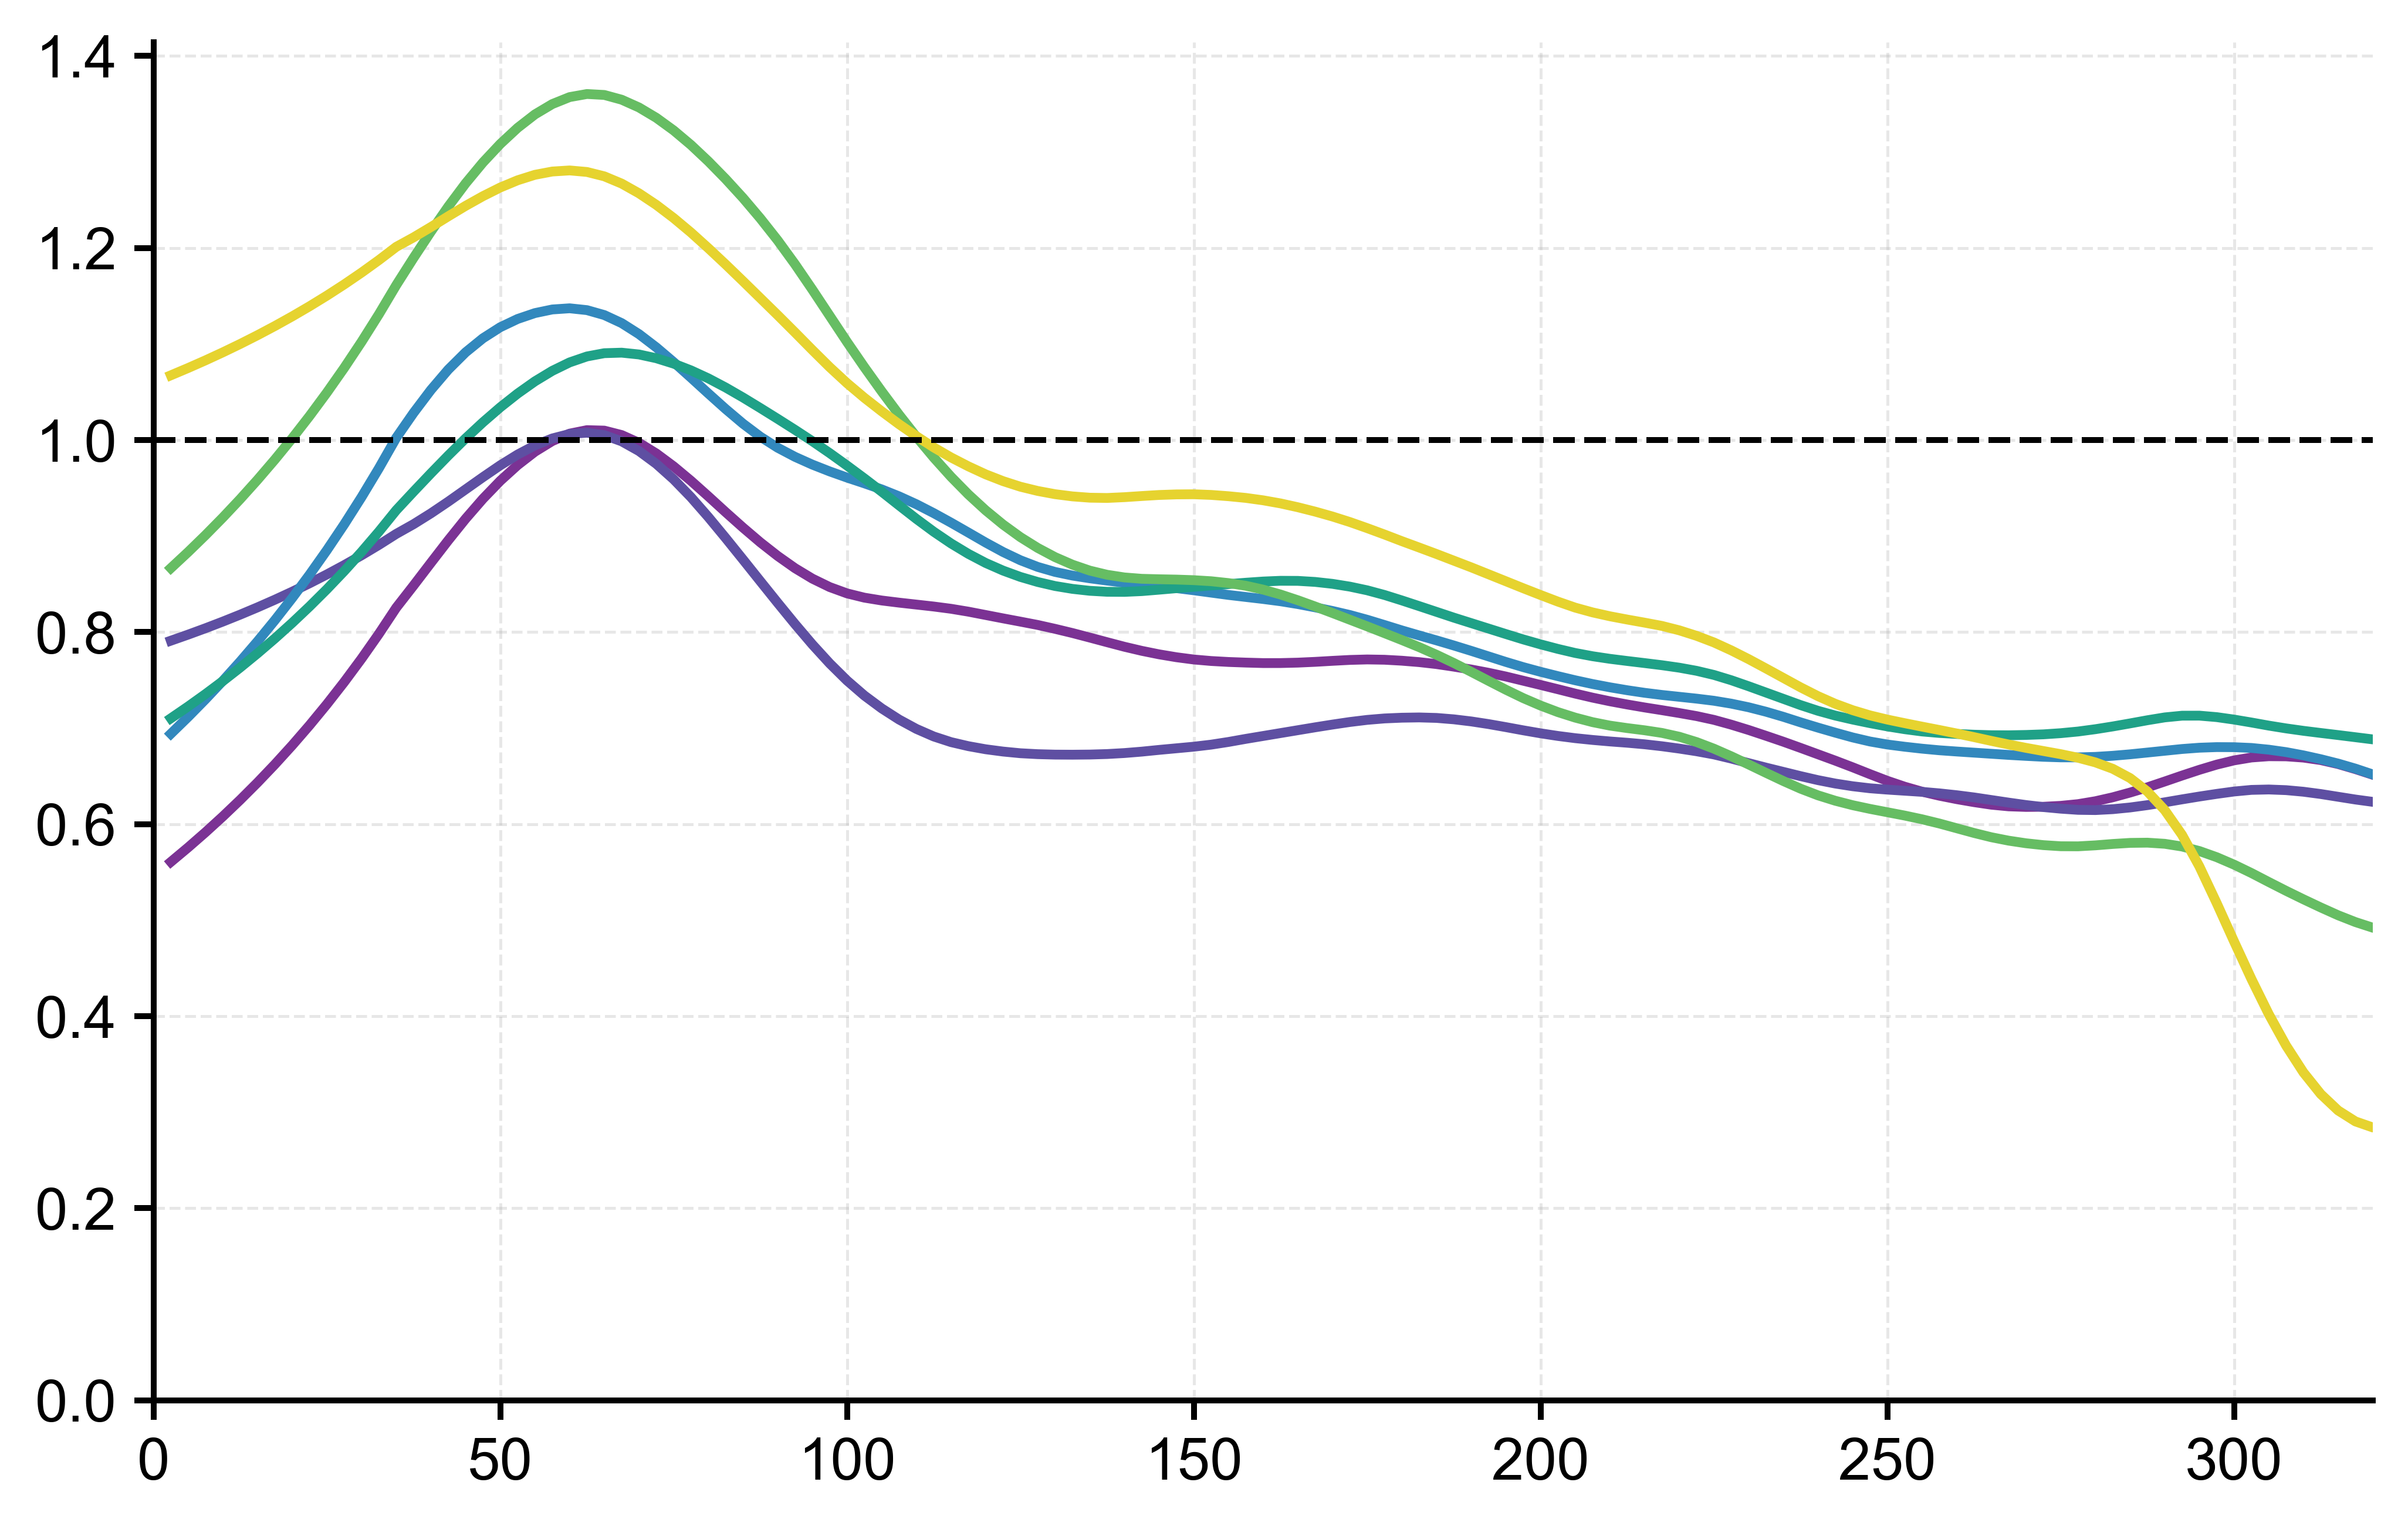

In [59]:
fig, ax = plt.subplots(figsize=(7, 4.5))

plot_stats = (
    results_3_topo
    .groupby(["Gyr (U)", "TopoI (U)", "time_min", "DNA Template", "[DNA] (nM)", "[RNAP] (nM)"])
    .agg(
        mean=("rate_corrected", "mean"),
        std=("rate_corrected", "std"),
        count=("rate_corrected", "count"),
    )
    .reset_index()
)

# Baseline = 0 U TopoI
baseline = (
    plot_stats[plot_stats["TopoI (U)"] == 0]
    [["Gyr (U)", "time_min", "mean"]]
    .rename(columns={"mean": "baseline"})
)

# Fold change vs 0 U TopoI
plot_stats = plot_stats.merge(
    baseline,
    on=["Gyr (U)", "time_min"],
    how="left",
)

plot_stats["fold_change"] = plot_stats["mean"] / plot_stats["baseline"]
plot_stats["fold_change_std"] = plot_stats["std"] / plot_stats["baseline"]


colors = {
    0.08: "#7B3294",
    0.17: "#5E4FA2",
    0.33: "#3288BD",
    0.67: "#1FA187",
    1.33: "#66BD63",
    2.66: "#E6D32F",
}

topoi_values = np.array(list(colors.keys()))

for (gyr, topoi), d in plot_stats[plot_stats["TopoI (U)"] != 0].groupby(
    ["Gyr (U)", "TopoI (U)"]
):
    d = d.sort_values("time_min")
    x = d["time_min"]
    y = d["fold_change"]
    sd = d["fold_change_std"]

    ax.plot(
        x,
        y,
        color=colors[topoi_values[np.argmin(np.abs(topoi_values - topoi))]],
        lw=2,
    )

    ax.fill_between(
        x,
        y - sd,
        y + sd,
        color=colors[topoi_values[np.argmin(np.abs(topoi_values - topoi))]],
        alpha=0.15,
        lw=0,
    )

# Baseline
ax.axhline(1, color="black", ls="--", lw=1.2)

ax.set_xlim(0, 320)
ax.set_ylim(0, None)
ax.grid(True, ls="--", lw=0.6, alpha=0.3)

ax.spines[["top", "right"]].set_visible(False)
ax.tick_params(direction="out", width=1.2, length=4)

save_path = Path("../figures/fig3_topo_TX_analysis.pdf")
plt.savefig(save_path)

plt.tight_layout()
plt.show()

## Figure 3: Gyr effet = f(RNAP/DNA)

### 1. Load data



In [ ]:
# ------------------------------------------------------------------------------

df_4_rx = df[
    (df["TopoI (U)"] == 0) &
    (df["DNA Template"].str.contains("RX", na=False)) &
    (df["Gyr (U)"].isin([0, 2])) &
    (df["[RNAP] (nM)"] != 0) 
].copy()

# --------------------------------------------------------------------------
# GARDER LES COMBINAISONS DNA/RNAP QUI POSSÈDENT :
# - au moins un puits à 0 U Gyr
# - au moins un puits à 2 U Gyr
#
# Les deux conditions peuvent être :
# - dans le même Exp_ID
# - dans deux Exp_ID différents
# --------------------------------------------------------------------------

valid_pairs = (
    df_4_rx
    .groupby(
        ["[DNA] (nM)", "[RNAP] (nM)"]
    )["Gyr (U)"]
    .agg(lambda x: set(x) == {0, 2})
)

valid_pairs = valid_pairs[valid_pairs].index

df_4_rx = (
    df_4_rx
    .set_index(
        ["[DNA] (nM)", "[RNAP] (nM)"]
    )
    .loc[valid_pairs]
    .reset_index()
)

# --------------------------------------------------------------------------
# IDENTIFIER SI LA PAIRE EST :
# - INTRA-EXPÉRIENCE : 0 et 2 U Gyr dans le même Exp_ID
# - INTER-EXPÉRIENCES : 0 et 2 U Gyr dans des Exp_ID différents
# --------------------------------------------------------------------------

pair_type = (
    df_4_rx
    .groupby(
        ["[DNA] (nM)", "[RNAP] (nM)"]
    )
    .apply(
        lambda x: (
            "intra-expérience"
            if (
                x.loc[x["Gyr (U)"] == 0, "Exp_ID"].isin(
                    x.loc[x["Gyr (U)"] == 2, "Exp_ID"]
                ).any()
            )
            else "inter-expériences"
        ),
        include_groups=False,
    )
    .rename("Pair_type")
    .reset_index()
)

df_4_rx = df_4_rx.merge(
    pair_type,
    on=["[DNA] (nM)", "[RNAP] (nM)"],
    how="left",
)

df_4_rx = df_4_rx[
    ~(
        (df_4_rx["Exp_ID"] == "TL39 TX46") &
        (df_4_rx["Well"] == "H10")
    )
].copy()
# --------------------------------------------------------------------------
# VÉRIFICATION
# --------------------------------------------------------------------------

print(
    df_4_rx[
        [
            "Exp_ID",
            "Well",
            "[DNA] (nM)",
            "[RNAP] (nM)",
            "Gyr (U)",
            "TopoI (U)",
            "DNA Template",
            "Pair_type",
        ]
    ]
    .drop_duplicates()
    .sort_values(
        [
            "[DNA] (nM)",
            "[RNAP] (nM)",
            "Exp_ID",
            "Gyr (U)",
            "Well",
        ]
    )
)

print("=== TRANSCRIPTION DATASET SUMMARY ===")
print(f"Selected rows       : {len(df_4_rx)}")
print(f"Total experiments   : {df_4_rx['Exp_ID'].nunique()}")
print(
    f"Total wells analyzed: "
    f"{df_4_rx[['Exp_ID', 'Well']].drop_duplicates().shape[0]}"
)

print("\n=== PAIR TYPES ===")
print(
    df_4_rx[
        ["[DNA] (nM)", "[RNAP] (nM)", "Pair_type"]
    ]
    .drop_duplicates()
    .sort_values(
        ["[DNA] (nM)", "[RNAP] (nM)"]
    )
)

# --------------------------------------------------------------------------
# BLANKS DES EXPÉRIENCES RETENUES
# --------------------------------------------------------------------------

blank_df_4_rx = df[
    (df["Exp_ID"].isin(df_4_rx["Exp_ID"].unique())) &
    (df["DNA Template"] == "BLANK")
].copy()


#need to remove (df["Well"] != "H10") Exp_ID TX46

         Exp_ID Well  [DNA] (nM)  [RNAP] (nM)  Gyr (U)  TopoI (U)  \
0     TL39 TX42  F10      0.0340       34.000      0.0        0.0   
151   TL39 TX42  G10      0.0340       34.000      2.0        0.0   
302   TL39 TX40  B10      0.0340      170.000      0.0        0.0   
453   TL39 TX40  C10      0.0340      170.000      2.0        0.0   
604   TL39 TX42   F8      0.0510       51.000      0.0        0.0   
755   TL39 TX42   G8      0.0510       51.000      2.0        0.0   
906   TL39 TX40   B8      0.0510      255.000      0.0        0.0   
1057  TL39 TX40   C8      0.0510      255.000      2.0        0.0   
1359  TL39 TX44  B16      0.0534      267.000      0.0        0.0   
1208  TL39 TX44  B10      0.0534      267.000      2.0        0.0   
1510  TL39 TX42   F6      0.0680       68.000      0.0        0.0   
1661  TL39 TX42   G6      0.0680       68.000      2.0        0.0   
1812  TL39 TX42   I4      0.0680      255.000      0.0        0.0   
1963  TL39 TX42   I8      0.0680  

### 2. Deconvolution + rate computation + inactivation correction 


In [158]:
# ==============================================================================
# ANALYZE SELECTED WELLS
# ==============================================================================

results_4_rx = analyze_wells(
    df=df_4_rx,
    blank_df=blank_df_4_rx,
    f_kernel=f_kernel,
    alpha_slope=alpha_slope,
    dt_min=DT_MIN,
    lambda_reg=LAMBDA_REG,
    window_min=WINDOW_MIN,
    polyorder=2,
    mode="interp",
)
print(results_4_rx)


         Exp_ID Well  Cycle DNA Template  [DNA] (nM)  [RNAP] (nM)  Gyr (U)  \
0     TL39 TX42  F10      1        RX MB       0.034         34.0      0.0   
1     TL39 TX42  F10      2        RX MB       0.034         34.0      0.0   
2     TL39 TX42  F10      3        RX MB       0.034         34.0      0.0   
3     TL39 TX42  F10      4        RX MB       0.034         34.0      0.0   
4     TL39 TX42  F10      5        RX MB       0.034         34.0      0.0   
...         ...  ...    ...          ...         ...          ...      ...   
5280  TL39 TX40   C4    147        RX MB       0.085        425.0      2.0   
5281  TL39 TX40   C4    148        RX MB       0.085        425.0      2.0   
5282  TL39 TX40   C4    149        RX MB       0.085        425.0      2.0   
5283  TL39 TX40   C4    150        RX MB       0.085        425.0      2.0   
5284  TL39 TX40   C4    151        RX MB       0.085        425.0      2.0   

      TopoI (U)  time_min      RFU_raw    RFU_blank  RFU_correc

## 3 . Plot

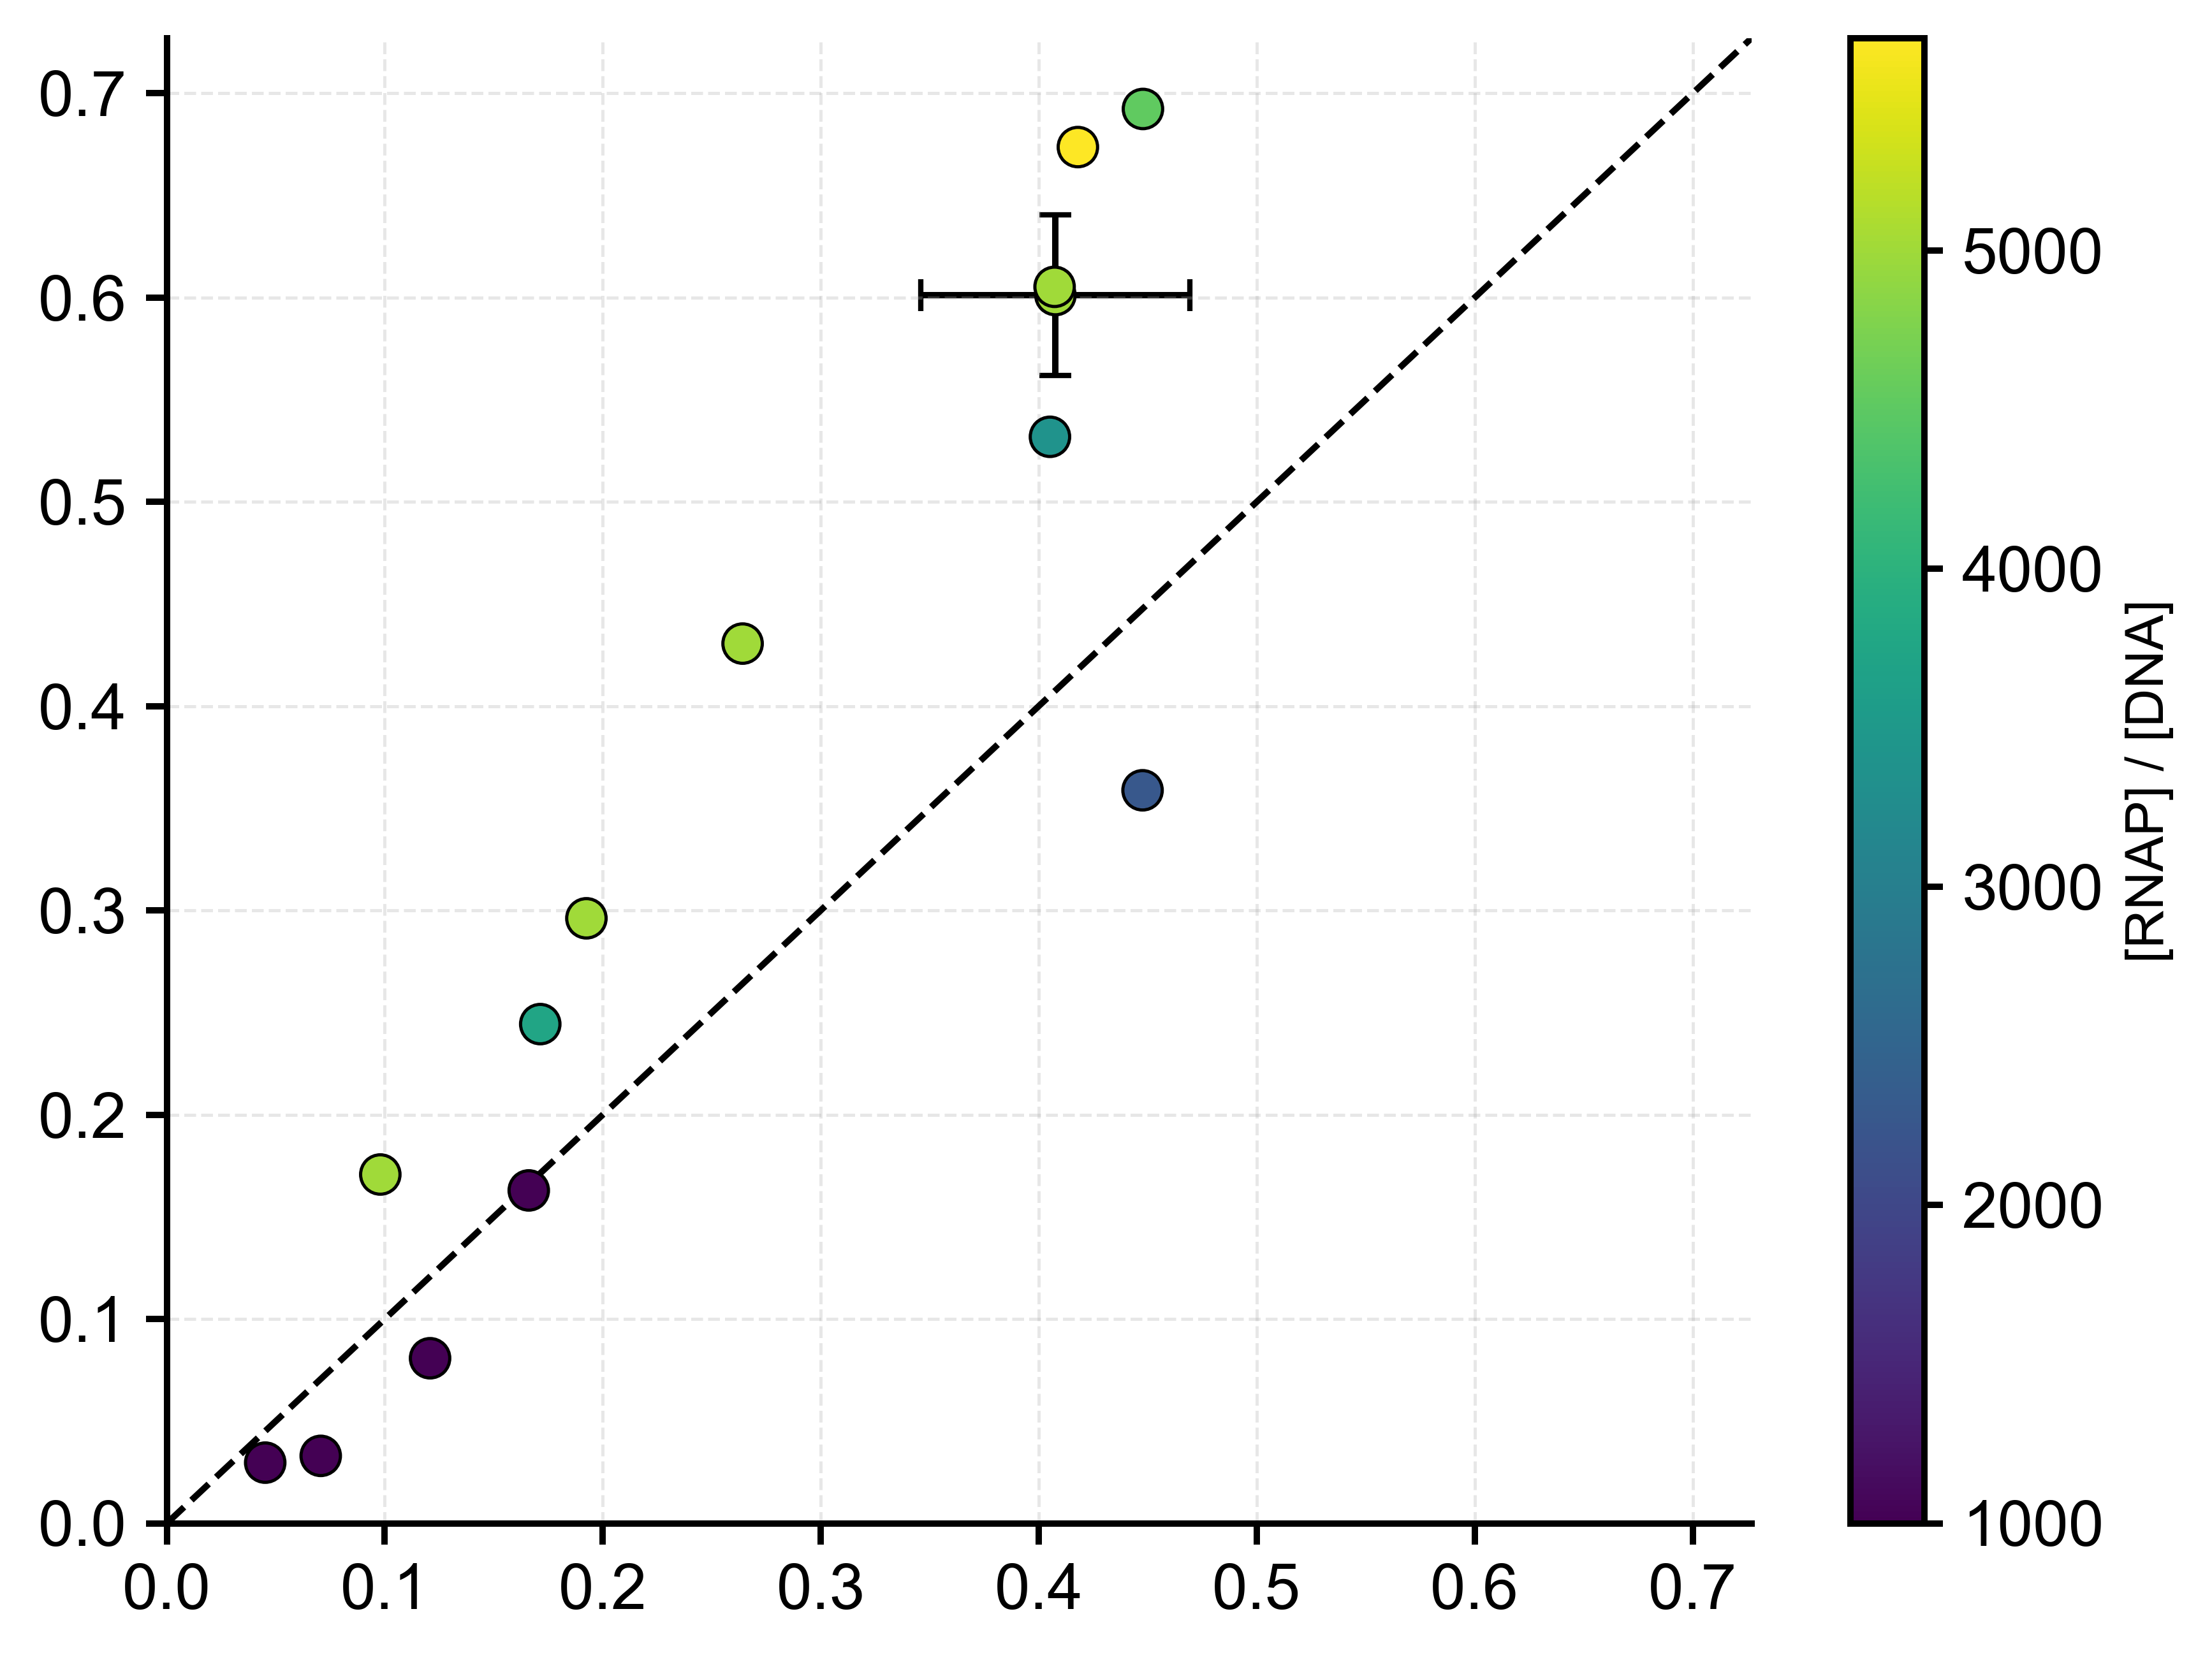

In [159]:
# ------------------------------------------------------------------------------

fig, ax = plt.subplots(figsize=(6, 4.5))

# --------------------------------------------------------------------------
# PARAMÈTRES
# --------------------------------------------------------------------------

time_min_start = 50
time_min_end = 150

# --------------------------------------------------------------------------
# 1. IDENTIFIER LES COMBINAISONS VALIDES
#    DNA + RNAP
#
#    Les conditions 0 U et 2 U Gyr peuvent être :
#    - dans le même Exp_ID
#    - dans des Exp_ID différents
# --------------------------------------------------------------------------

valid_keys = df_4_rx[
    [
        "[DNA] (nM)",
        "[RNAP] (nM)",
    ]
].drop_duplicates()

# --------------------------------------------------------------------------
# 2. SÉLECTION DES DONNÉES DE RATE
# --------------------------------------------------------------------------

df_plot = (
    results_4_rx
    .merge(
        valid_keys,
        on=[
            "[DNA] (nM)",
            "[RNAP] (nM)",
        ],
        how="inner",
    )
)

df_plot = df_plot[
    (df_plot["TopoI (U)"] == 0) &
    (df_plot["Gyr (U)"].isin([0, 2])) &
    (df_plot["time_min"] >= time_min_start) &
    (df_plot["time_min"] <= time_min_end)
].copy()

# --------------------------------------------------------------------------
# 3. MOYENNE TEMPORELLE POUR CHAQUE PUITS
#
# Chaque puits donne UNE valeur moyenne de production rate
# calculée uniquement sur la fenêtre temporelle choisie.
# --------------------------------------------------------------------------

well_stats = (
    df_plot
    .groupby(
        [
            "Exp_ID",
            "Well",
            "Gyr (U)",
            "[DNA] (nM)",
            "[RNAP] (nM)",
        ]
    )
    .agg(
        mean_rate=("rate_corrected", "mean"),
    )
    .reset_index()
)

# --------------------------------------------------------------------------
# 4. MOYENNE DES RÉPLICATS POUR CHAQUE CONDITION
#
# Les réplicats peuvent être :
# - dans le même Exp_ID
# - dans plusieurs Exp_ID
#
# On regroupe donc sur DNA + RNAP + Gyr,
# et non plus sur Exp_ID.
# --------------------------------------------------------------------------

condition_stats = (
    well_stats
    .groupby(
        [
            "Gyr (U)",
            "[DNA] (nM)",
            "[RNAP] (nM)",
        ]
    )
    .agg(
        mean=("mean_rate", "mean"),
        std=("mean_rate", "std"),
        n=("mean_rate", "count"),
    )
    .reset_index()
)

# --------------------------------------------------------------------------
# 5. GARDER UNIQUEMENT LES CONDITIONS AYANT 0 ET 2 U GYR
# --------------------------------------------------------------------------

paired_conditions = (
    condition_stats
    .groupby(
        [
            "[DNA] (nM)",
            "[RNAP] (nM)",
        ]
    )["Gyr (U)"]
    .agg(lambda x: set(x) == {0, 2})
)

paired_conditions = paired_conditions[paired_conditions].index

condition_stats = (
    condition_stats
    .set_index(
        [
            "[DNA] (nM)",
            "[RNAP] (nM)",
        ]
    )
    .loc[paired_conditions]
    .reset_index()
)

# --------------------------------------------------------------------------
# 6. SÉPARER -GYR ET +GYR
# --------------------------------------------------------------------------

gyr_0 = (
    condition_stats[
        condition_stats["Gyr (U)"] == 0
    ]
    .rename(
        columns={
            "mean": "rate_minus_gyr",
            "std": "sd_minus_gyr",
            "n": "n_minus_gyr",
        }
    )
)

gyr_2 = (
    condition_stats[
        condition_stats["Gyr (U)"] == 2
    ]
    .rename(
        columns={
            "mean": "rate_plus_gyr",
            "std": "sd_plus_gyr",
            "n": "n_plus_gyr",
        }
    )
)

# --------------------------------------------------------------------------
# 7. APPARIEMENT
#    MÊME DNA + MÊME RNAP
#
#    L'Exp_ID n'intervient PLUS ici :
#    les paires inter-expériences sont donc conservées.
# --------------------------------------------------------------------------

paired = gyr_0.merge(
    gyr_2,
    on=[
        "[DNA] (nM)",
        "[RNAP] (nM)",
    ],
    how="inner",
)

# --------------------------------------------------------------------------
# 8. RATIO RNAP / DNA
# --------------------------------------------------------------------------

paired["RNAP_DNA_ratio"] = (
    paired["[RNAP] (nM)"] /
    paired["[DNA] (nM)"]
)

# --------------------------------------------------------------------------
# 9. BARRES D'ERREUR
#
# x = -Gyr
# y = +Gyr
#
# Si n = 1 -> pas de barre d'erreur
# Si n > 1 -> SD affichée
# --------------------------------------------------------------------------

xerr = paired["sd_minus_gyr"].fillna(0)
yerr = paired["sd_plus_gyr"].fillna(0)

# --------------------------------------------------------------------------
# 10. LIMITES DES AXES
# --------------------------------------------------------------------------

max_rate = max(
    paired["rate_minus_gyr"].max(),
    paired["rate_plus_gyr"].max(),
)

max_rate *= 1.05

# --------------------------------------------------------------------------
# 11. LIGNE x = y
# --------------------------------------------------------------------------

ax.plot(
    [0, max_rate],
    [0, max_rate],
    color="black",
    ls="--",
    lw=1.2,
)

# --------------------------------------------------------------------------
# 12. POINTS
# --------------------------------------------------------------------------

scatter = ax.scatter(
    paired["rate_minus_gyr"],
    paired["rate_plus_gyr"],
    c=paired["RNAP_DNA_ratio"],
    cmap="viridis",
    s=55,
    edgecolor="black",
    linewidth=0.6,
    zorder=2,
)

# --------------------------------------------------------------------------
# 13. BARRES D'ERREUR
# --------------------------------------------------------------------------

ax.errorbar(
    paired["rate_minus_gyr"],
    paired["rate_plus_gyr"],
    xerr=xerr,
    yerr=yerr,
    fmt="none",
    ecolor="black",
    elinewidth=1.2,
    capsize=3,
    zorder=1,
)

# --------------------------------------------------------------------------
# 14. COLORBAR
# --------------------------------------------------------------------------

cbar = plt.colorbar(scatter, ax=ax)

cbar.set_label(
    "[RNAP] / [DNA]",
    fontsize=10,
)

# --------------------------------------------------------------------------
# 15. STYLE
# --------------------------------------------------------------------------

ax.set_xlim(0, max_rate)
ax.set_ylim(0, max_rate)

ax.grid(
    True,
    ls="--",
    lw=0.6,
    alpha=0.3,
)

ax.spines[["top", "right"]].set_visible(False)

ax.tick_params(
    direction="out",
    width=1.2,
    length=4,
)

# --------------------------------------------------------------------------
# 16. SAUVEGARDE
# --------------------------------------------------------------------------

plt.tight_layout()

save_path = Path("../figures/fig_4_RX_Gyr.pdf")
plt.savefig(save_path)

plt.show()

In [160]:

# ------------------------------------------------------------------------------

df_4_lin = df[
    (df["TopoI (U)"] == 0) &
    (df["DNA Template"].str.contains("LIN", na=False)) &
    (df["Gyr (U)"].isin([0, 2]))
].copy()

# keep pairs of wells from the same experiment
# with the same [DNA] and [RNAP] but different Gyr (0 and 2 U)
pairs = (
    df_4_lin
    .groupby(["Exp_ID", "[DNA] (nM)", "[RNAP] (nM)"])["Gyr (U)"]
    .nunique()
)

pairs = pairs[pairs == 2].index

df_4_lin = (
    df_4_lin
    .set_index(["Exp_ID", "[DNA] (nM)", "[RNAP] (nM)"])
    .loc[pairs]
    .reset_index()
)

print("=== TRANSCRIPTION DATASET SUMMARY ===")
print(f"Selected rows       : {len(df_4_lin)}")
print(f"Total experiments   : {df_4_lin['Exp_ID'].nunique()}")
print(
    f"Total wells analyzed: "
    f"{df_4_lin[['Exp_ID', 'Well']].drop_duplicates().shape[0]}"
)


blank_df_4_lin = df[
    (df["Exp_ID"].isin(df_4_lin["Exp_ID"].unique())) &
    (df["DNA Template"] == "BLANK")
].copy()

=== TRANSCRIPTION DATASET SUMMARY ===
Selected rows       : 3624
Total experiments   : 3
Total wells analyzed: 24


In [161]:



results_4_lin = analyze_wells(
    df=df_4_lin,
    blank_df=blank_df_4_lin,
    f_kernel=f_kernel,
    alpha_slope=alpha_slope,
    dt_min=DT_MIN,
    lambda_reg=LAMBDA_REG,
    window_min=WINDOW_MIN,
    polyorder=2,
    mode="interp",
)
print(results_4_lin)


         Exp_ID Well  Cycle DNA Template  [DNA] (nM)  [RNAP] (nM)  Gyr (U)  \
0     TL39 TX40  E10      1       LIN MB       0.034        170.0      0.0   
1     TL39 TX40  E10      2       LIN MB       0.034        170.0      0.0   
2     TL39 TX40  E10      3       LIN MB       0.034        170.0      0.0   
3     TL39 TX40  E10      4       LIN MB       0.034        170.0      0.0   
4     TL39 TX40  E10      5       LIN MB       0.034        170.0      0.0   
...         ...  ...    ...          ...         ...          ...      ...   
3619  TL39 TX45   C4    147       LIN MB       0.025        375.0      2.0   
3620  TL39 TX45   C4    148       LIN MB       0.025        375.0      2.0   
3621  TL39 TX45   C4    149       LIN MB       0.025        375.0      2.0   
3622  TL39 TX45   C4    150       LIN MB       0.025        375.0      2.0   
3623  TL39 TX45   C4    151       LIN MB       0.025        375.0      2.0   

      TopoI (U)  time_min      RFU_raw    RFU_blank  RFU_correc